#**M3 Phase: Unsupervised Machine Learning for Grant Description and Integrated Sub-Topic Analysis**

**US Government Grant Opportunities Dataset**

By: Maggie Croghan Team 11

##**Domain Question**

How can clustering grant descriptions uncover meaningful sub-topic categories beyond broad classifications, and what do these finer-grained categories reveal about patterns of funding concentration, gaps, and potentially underserved areas within the grant landscape?

*domain question 3*

##**Problem Statement**

This analysis dives into grant descriptions (from the *grant_opportunities_details* dataset) to discover the sub-domains within the broader categories and offer greater insight into what grants in these categories are actually serving.

This analysis can provide value insights for funding agencies who may be interested in diversifying their grants or for adovacy groups interested in the bringing awareness to the underserved groups within grant funding.

Each category is clustered independently and uses grant descriptions as the sole input. This analysis focuses on the five categories with the most grants to ensure each model has sufficient data points for clustering. Initial EDA revealed that the top categories, in order, were Health, Science, Education, Other, and Environment.



##**M4 Key Updates**

- Text Preprocessing Refinement
- UMAP hyperparameter tuning
- K-Means vs DBSCAN model comparison
- Additional post-clustering analysis


# **Data Import and Initial Cleaning**


**Updates**
*  Did *not* drop rows with duplicate descriptions
*  Did *not* fill estimated funding NaNs with 0

This change was made to preserve more of the original data. Duplicate descriptions were a result of filling missing descriptions with their title or poor descriptions. Given the granualr nature of my analysis, preserving the count of grants in each sub-topic was prefferable.

I also wanted to be able to evaluate where the true funding estimates were, not skewed by additional 0s, so I decided to keep estimated funding as NaNs.

In [264]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

warnings.filterwarnings(
    "ignore",
    message="n_jobs value .* overridden .* random_state"
)

warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import re

# IMPORT DATA
grants = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grants.csv",
    low_memory=False
)

details = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grant_opportunity_details.csv",
    low_memory=False
)


# CLEAN COLUMN NAMES
def clean_names(df):
    df.columns = (
        df.columns
        .str.lower()
        .str.strip()
        .str.replace(" ", "_")
        .str.replace(r"[^\w]", "", regex=True)
    )
    return df

grants = clean_names(grants)
details = clean_names(details)


# CLEAN DATE COLUMNS
date_cols = [col for col in details.columns if "date" in col]

for col in date_cols:
    details[col] = pd.to_datetime(
        details[col],
        errors="coerce"
    )


# ENSURE BOOLEAN TYPE FOR ELIGIBILITY COLUMNS
eligibility_cols = [
    "eligibility_individuals",
    "eligibility_state_governments",
    "eligibility_county_governments",
    "eligibility_independent_school_districts",
    "eligibility_city_or_township_governments",
    "eligibility_special_district_governments",
    "eligibility_native_american_tribal_governments_federally_recognized",
    "eligibility_native_american_tribal_organizations_other",
    "eligibility_nonprofits_501c3",
    "eligibility_nonprofits_non_501c3",
    "eligibility_for_profit",
    "eligibility_small_businesses",
    "eligibility_private_institutions_of_higher_education",
    "eligibility_public_institutions_of_higher_education",
    "eligibility_public_indian_housing_authorities",
    "eligibility_others",
    "eligibility_unrestricted"
]

for col in eligibility_cols:
    if col in details.columns:
        details[col] = details[col].astype(bool)


# ENSURE BOOLEAN TYPE FOR FUNDING INSTRUMENT TYPES
funding_cols = [
    "funding_cooperative_agreement",
    "funding_grant",
    "funding_procurement_contract",
    "funding_other"
]

for col in funding_cols:
    if col in details.columns:
        details[col] = details[col].astype(bool)


# ENSURE BOOLEAN TYPE FOR ALL CATEGORY COLUMNS
category_cols = [
    "category_agriculture",
    "category_arts",
    "category_business",
    "category_community_development",
    "category_consumer_protection",
    "category_disaster",
    "category_education",
    "category_employment",
    "category_energy",
    "category_environment",
    "category_food",
    "category_health",
    "category_housing",
    "category_humanities",
    "category_iija",
    "category_income_security",
    "category_info",
    "category_law",
    "category_natural_resources",
    "category_opportunity_zone",
    "category_regional_development",
    "category_science",
    "category_transportation",
    "category_other"
]

for col in category_cols:
    if col in details.columns:
        details[col] = details[col].astype(bool)

# CLEAN NUMERIC COLUMNS
numeric_cols = [
    "estimated_total_program_funding",
    "award_ceiling",
    "award_floor",
    "expected_number_of_awards"
]

for col in numeric_cols:
    if col in details.columns:
        details[col] = (
            details[col]
            .astype(str)
            .str.replace(r"[^\d.]", "", regex=True)
        )
        details[col] = pd.to_numeric(
            details[col],
            errors="coerce"
        )


# Fill missing descriptions
details['description'] = details['description'].fillna(details['funding_opportunity_title'])

# Create a single 'official_category' label by finding the first True category column
cat_cols = [c for c in details.columns if c.startswith('category_') and c != 'category_explanation']
details['official_category'] = details[cat_cols].idxmax(axis=1).str.replace('category_', '')

print("Grants shape:", grants.shape)
print("Details shape:", details.shape)

print("\nCategory columns:", len(category_cols))

details.head()

Grants shape: (74669, 17)
Details shape: (2000, 69)

Category columns: 24


,opportunity_id,funding_opportunity_number,funding_opportunity_title,opportunity_category,opportunity_category_explanation,expected_number_of_awards,cost_sharing_or_matching_requirement,version,posted_date,last_updated_date,...,category_info,category_law,category_natural_resources,category_opportunity_zone,category_regional_development,category_science,category_transportation,category_other,category_explanation,official_category
0,40112,DHS-FEMACAPSSSE-08-001,Community Assistance Program State Support Ser...,Discretionary,NaN,52.0,True,1,2007-11-28,2007-11-28,...,False,False,False,False,False,False,False,True,The purpose of the Community Assistance Progra...,other
1,40113,DHS-FEMACAPSSSE-08-001,Community Assistance Program State Support Ser...,Discretionary,NaN,52.0,True,1,2007-11-28,2007-11-28,...,False,False,False,False,False,False,False,True,The purpose of the Community Assistance Progra...,other
2,42048,FWS-R4-FLEXFUND,Southeast Region Flex Funds,Discretionary,NaN,25.0,False,3,2008-06-17,2008-06-18,...,False,False,True,False,False,False,False,False,NaN,natural_resources
3,42423,306-08-027-RFI,Alternative Development Program,Discretionary,NaN,1.0,False,1,2008-07-22,2008-07-22,...,False,False,False,False,False,False,False,False,NaN,agriculture
4,45657,04-563,Developing Country Collaborations in Plant Gen...,Discretionary,NaN,NaN,True,2,2004-03-22,2009-03-03,...,False,False,False,False,False,True,False,False,NaN,science


In [3]:
details['official_category'].value_counts()

,count
official_category,
health,590
science,447
education,442
other,114
environment,102
energy,51
food,47
natural_resources,40
agriculture,25


### **Text Cleaning/Preprocessing**

####**New Preprocessing**

Unicode Normalization:

NFKC normalization transforms "compatible" characters into a standard form, effectively unifying characters that might look visually similar but have different underlying Unicode code points. This allows strings that are visually identical to compare as equal.

Key effects of using "NFKC" include:
* Replacing full-width characters with half-width ones (digits １２３ are converted to standard digits 123)
* Converting ligatures to their base characters (A character like "ﬀi" is expanded into the sequence of three characters "f", "f", "i")
* Standardizing vulgar fractions and superscripts
* Unifying character representations (e.g.,  "Å" vs "A")

In [4]:
import re
import unicodedata
import numpy as np

details["cleaned_description"] = details["description"]
text_cols = ["cleaned_description"]


# Unicode normalization (fix encoding issues)
for col in text_cols:
    if col in details.columns:
        details[col] = details[col].astype(str)
        details[col] = details[col].apply(lambda x: unicodedata.normalize("NFKC", x)) # Fix unicode normalization

# Fix encoding artifacts common in grant data
for col in text_cols:
    if col in details.columns:
        details[col] = details[col].str.replace("", "'", regex=False)
        details[col] = details[col].str.replace("", '"', regex=False)
        details[col] = details[col].str.replace("", '"', regex=False)
        details[col] = details[col].str.replace("–", "-", regex=False)
        details[col] = details[col].str.replace("—", "-", regex=False)

# Remove URLs and emails
for col in text_cols:
    if col in details.columns:
        details[col] = details[col].str.replace(r"http\S+", " ", regex=True)
        details[col] = details[col].str.replace(r"www\S+", " ", regex=True)
        details[col] = details[col].str.replace(r"\S+@\S+", " ", regex=True)

# Remove solicitation codes (NSF 04-510, PD 98-1331, etc.)
for col in text_cols:
    if col in details.columns:
        details[col] = details[col].str.replace(r"\b[A-Z]{2,5}[- ]?\d{2,6}\b", " ", regex=True)

# Remove administrative / boilerplate phrases
boilerplate_patterns = [
    r"subject to the availability of funds",
    r"availability of funds",
    r"applicants shall",
    r"applicants must",
    r"applicants should",
    r"applicants are encouraged to",
    r"proposal will be evaluated",
    r"proposals will be evaluated",
    r"full and open competition",
    r"request for applications",
    r"request for proposals",
    r"notice of funding opportunity",
    r"intellectual merit",
    r"broader impacts",
    r"data management plan",
    r"program solicitation",
    r"solicitation number",
    r"please visit",
    r"for more information"
]

combined_pattern = "|".join(boilerplate_patterns)

for col in text_cols:
    if col in details.columns:
        details[col] = details[col].str.replace(combined_pattern," ", regex=True, case=False)

# Normalize whitespace
for col in text_cols:
    if col in details.columns:
        details[col] = details[col].str.replace(r"\s+", " ", regex=True)
        details[col] = details[col].str.strip()


In [5]:
# OPTIONAL: chunk long descriptions for embedding
MAX_WORDS = 200

details["description_chunks"] = details["cleaned_description"].apply(
    lambda x: [
        " ".join(x.split()[i:i+MAX_WORDS])
        for i in range(0, len(x.split()), MAX_WORDS)
    ]
)

#**Unsupervised Machine Learning**

## **Health Category Clustering**

### **Create Health DataFrame**

In [6]:
details_health = details[details['official_category'] == 'health']
details_health.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,590.000000,63.000000,590.000000,590,590,585,584,564,6.000000e+01,2.750000e+02,6.500000e+01
mean,339878.200000,23.841270,1.452542,2022-06-07 15:42:06.101694976,2022-08-16 16:01:37.627118592,2024-09-06 09:43:23.076923136,2024-10-21 22:50:57.534246656,2024-12-22 01:39:34.468084992,5.900390e+07,8.360687e+06,2.312462e+06
min,58617.000000,0.000000,1.000000,2010-11-01 00:00:00,2012-01-27 00:00:00,2011-04-15 00:00:00,2018-06-15 00:00:00,2023-10-29 00:00:00,5.000000e+05,0.000000e+00,0.000000e+00
25%,335412.500000,4.000000,1.000000,2021-09-22 00:00:00,2021-12-12 18:00:00,2023-11-22 00:00:00,2023-12-05 00:00:00,2024-02-07 18:00:00,3.900000e+06,2.500000e+05,0.000000e+00
50%,344395.500000,10.000000,1.000000,2022-11-10 00:00:00,2023-01-11 00:00:00,2024-07-05 00:00:00,2024-07-12 12:00:00,2024-10-11 12:00:00,1.705750e+07,4.000000e+05,0.000000e+00
75%,348426.500000,28.000000,1.000000,2023-06-12 00:00:00,2023-06-29 18:00:00,2025-05-25 00:00:00,2025-05-26 00:00:00,2025-07-09 00:00:00,6.997500e+07,1.000000e+06,1.500000e+05
max,350383.000000,163.000000,18.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2031-12-06 00:00:00,2029-12-31 00:00:00,2040-01-01 00:00:00,5.000000e+08,5.000000e+08,7.300000e+07
std,20029.449628,31.423335,1.547313,NaN,NaN,NaN,NaN,NaN,1.041851e+08,4.220879e+07,9.894189e+06


### **Text Embedding**


In [7]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("BAAI/bge-large-en-v1.5")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

In [8]:
details_health["description_chunks"] = details_health["description_chunks"].apply(
    lambda chunks: [
        "Represent this sentence for clustering: " + chunk
        for chunk in chunks
    ]
)

# Average embeddings across chunks
details_health["embedding"] = details_health["description_chunks"].apply(
    lambda chunks: np.mean(
        embedding_model.encode(
            chunks,
            batch_size=64,
            normalize_embeddings=True,
            convert_to_numpy=True
        ),
        axis=0
    ).astype(np.float32)
)

embeddings_health = np.vstack(details_health["embedding"].values)

/tmp/ipython-input-1897383631.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_health["description_chunks"] = details_health["description_chunks"].apply(
/tmp/ipython-input-1897383631.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_health["embedding"] = details_health["description_chunks"].apply(


### **K-Means Elbow Test**

In [11]:
# initial UMAP parameters for K-Means Visualizations
import umap

umap_model = umap.UMAP(
    n_components=8,
    n_neighbors=10,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

embeddings_health_umap = umap_model.fit_transform(embeddings_health)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


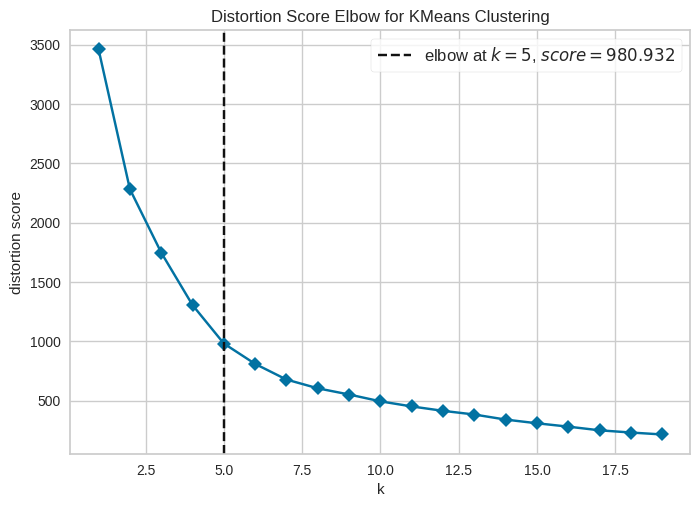

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [12]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(
    init="k-means++", # new
    n_init=10,      # increase iterations
    max_iter=500,   # new -- ensures convergence
    random_state=42
)

visualizer = KElbowVisualizer(
    model,
    k=(1, 20),                 # test cluster range
    metric="distortion",
    timings=False
)

visualizer.fit(embeddings_health_umap)
visualizer.show()

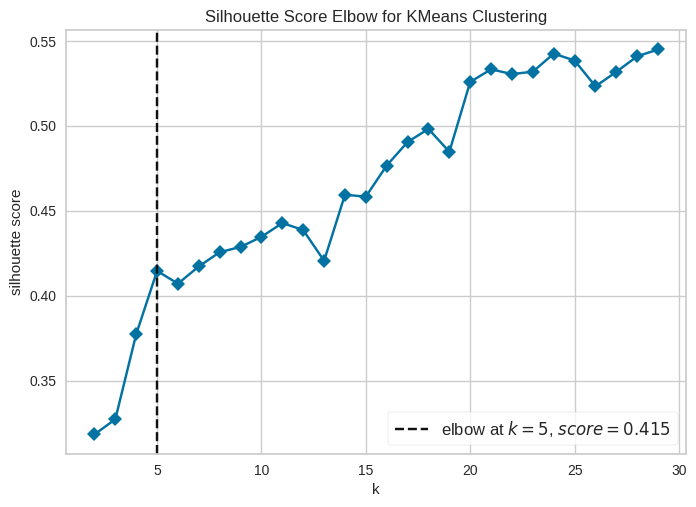

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [13]:
visualizer = KElbowVisualizer(
    model,
    k=(2, 30),                 # test cluster range
    metric="silhouette",
    timings=False
)

visualizer.fit(embeddings_health_umap)
visualizer.show()

### **K-Means Clustering Hypertuning**

In [14]:
import umap
import hdbscan
import numpy as np
from sklearn.metrics import silhouette_score

n_neighbors_values = [5, 8, 10, 15]
n_components_values = [5, 8, 10]
n_clusters_values = [5, 11, 14, 18, 21, 24, 29]

n_clusters value were chosen based on local maximums seem on silhoutte score visualization.

In [38]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score


k_means_results = []

for n_neighbors in n_neighbors_values:
    for n_components in n_components_values:

        umap_model = umap.UMAP(
            n_neighbors=n_neighbors,
            n_components=n_components,
            min_dist=0.0,
            metric='cosine',
            random_state=42
        )

        reduced = umap_model.fit_transform(embeddings_health)

        for n_clusters in n_clusters_values:

                clusterer = KMeans(
                   n_clusters=n_clusters,
                   init="k-means++",
                   n_init=10,
                   max_iter=500,
                   random_state=42
                )

                labels_kmeans = clusterer.fit_predict(reduced)

                silhouette = silhouette_score(
                    reduced,
                    labels_kmeans
                )

                db_k_means = davies_bouldin_score(reduced, labels_kmeans)

                ch_k_means = calinski_harabasz_score(reduced, labels_kmeans)

                k_means_results.append({
                    "n_neighbors": n_neighbors,
                    "n_components": n_components,
                    "n_clusters": n_clusters,
                    "silhouette": silhouette,
                    "davies_bouldin": db_k_means,
                    "calinski_harabasz": ch_k_means
                })

### **HDBSCAN Clustering**

In [20]:
!pip install hdbscan --quiet

In [21]:
import umap
import hdbscan
import numpy as np
from sklearn.metrics import silhouette_score

n_neighbors_values = [5, 8, 10, 15]
n_components_values = [5, 8, 10]
min_cluster_size_values = [5, 8, 12, 15]
min_samples_values = [2, 3, 5]


In [43]:
dbscan_results = []

for n_neighbors in n_neighbors_values:
    for n_components in n_components_values:

        umap_model = umap.UMAP(
            n_neighbors=n_neighbors,
            n_components=n_components,
            min_dist=0.0,
            metric='cosine',
            random_state=42
        )

        reduced = umap_model.fit_transform(embeddings_health)

        for min_cluster_size in min_cluster_size_values:
            for min_samples in min_samples_values:

                clusterer = hdbscan.HDBSCAN(
                    min_cluster_size=min_cluster_size,
                    min_samples=min_samples,
                    metric='euclidean',
                    cluster_selection_method='leaf'
                )

                labels_hdbscan = clusterer.fit_predict(reduced)

                # Skip if only 1 cluster
                num_clusters = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)

                if num_clusters < 3:
                    continue

                # Skip if too many clusters
                if num_clusters > 50:
                    continue

                # Remove noise points for silhouette score
                mask = labels_hdbscan != -1

                if len(set(labels_hdbscan[mask])) < 2:
                    continue

                silhouette = silhouette_score(
                    reduced[mask],
                    labels_hdbscan[mask]
                )

                noise_pct = np.mean(labels_hdbscan == -1)

                persistence = np.mean(clusterer.cluster_persistence_)

                db_hdbscan = davies_bouldin_score(reduced[mask], labels_hdbscan[mask])

                ch_hdbscan = calinski_harabasz_score(reduced[mask], labels_hdbscan[mask])

                dbscan_results.append({
                    "n_neighbors": n_neighbors,
                    "n_components": n_components,
                    "min_cluster_size": min_cluster_size,
                    "min_samples": min_samples,
                    "num_clusters": num_clusters,
                    "silhouette": silhouette,
                    "noise_pct": noise_pct,
                    "persistence": persistence,
                    "davies_bouldin": db_hdbscan,
                    "calinski_harabasz": ch_hdbscan
                })


### **Model Comparision**


Score for Evaluation:
- Silhouette: balances cohesion vs separation
  - ~0.4–0.7 → strong semantic clustering
  - Limitation: assumes clusters should be well separated and convex, which is not always true for text and can undervalue density clustering.
- Noise Percentage (DBSCAN only): The fraction of grants labeled noise
  - 5–35% → healthy semantic boundary detection
  - Noise can be helpful for identifying interdisciplinary grants, vague descriptions, outliers, or emerging topics
- Persistence (DBSCAN only): Does this cluster exist strongly, or only barely?
  - tells us if a cluster is a real subdomain vs accidental grouping
  - greater than 0.5 → very stable
  - 0.3 - 0.5 → meaningful
  - < 0.2 → weak / boundary cluster
- Davis Bouldin Score: Are clusters compact and far apart?
  - focuses more on cluster compactness than silhouette
  - ~0.4-0.7 is strong for text (lower score is better)
- Calinski-Harabasz: How much variance exists between clusters?
  - favors many well-separated clusters
  - higher score is better
  - limitation: can reward artificial splitting of continuous themes


In [46]:
dbscan_results_df = pd.DataFrame(dbscan_results)

dbscan_results_df_filtered = dbscan_results_df[(dbscan_results_df['silhouette'] > 0.40) & (dbscan_results_df['persistence'] > 0.27) & (dbscan_results_df['noise_pct'].between(0.05, 0.35))]

dbscan_results_df_filtered

,n_neighbors,n_components,min_cluster_size,min_samples,num_clusters,silhouette,noise_pct,persistence,davies_bouldin,calinski_harabasz
38,8,5,15,3,16,0.577677,0.222034,0.291250,0.568238,678.929016
61,10,5,8,2,31,0.600674,0.183051,0.271615,0.547006,719.679321
75,10,8,12,3,18,0.547335,0.149153,0.274296,0.604570,613.306946


In [47]:
k_means_results_df = pd.DataFrame(k_means_results)

k_means_results_df_filtered = k_means_results_df[(k_means_results_df['silhouette'] > 0.40) & (k_means_results_df['davies_bouldin'] < 0.7) & (k_means_results_df['calinski_harabasz'] > 800)]

k_means_results_df_filtered.sort_values(by=['silhouette', 'davies_bouldin'], ascending=[False, True])

,n_neighbors,n_components,n_clusters,silhouette,davies_bouldin,calinski_harabasz
6,5,5,29,0.570422,0.571567,1107.722778
5,5,5,24,0.558678,0.576222,884.717346
34,8,8,29,0.557390,0.575802,864.907349
13,5,8,29,0.556978,0.586100,1019.452576
20,5,10,29,0.539360,0.578777,918.320129
12,5,8,24,0.533681,0.637148,872.039978
11,5,8,21,0.528946,0.635956,806.348511
19,5,10,24,0.519853,0.638584,845.256287


**DBSCAN Best Model** *(31 clusters)*

Hyperparameters:
- n_neighbors: 10
- n_componenets: 5
- min_cluster_size: 8
- min_samples: 2

Scores:
- Silhouette: 0.6007 --> strong
- Noise percentage: 18.3% --> excellent (captures interdisciplinary / weakly defined grants)
- Persistence: 0.2716 --> moderately stable clusters (may capture some accidental groupings instead of real subdomains)
- Davies Bouldin: 0.5470 --> compact clusters
- Calinski Harabasz: 719.679 --> solid dispersion (can reward artificial splitting of continuous themes)


**Alternate Model for less clusters:** *(16 clusters)*
Hyperparameters:
- n_neighbors: 8
- n_componenets: 5
- min_cluster_size: 15
- min_samples: 3

Scores:
- Silhouette: 0.5777
- Noise percentage: 22.2%
- Persistence: 0.2913
- Davies Bouldin: 0.5682
- Calinski Harabasz: 678.929



**K-Means Best Model**

Hyperparameters:
- n_neighbors: 5
- n_componenets: 5
- n_clusters: 29

Scores:
- Silhouette: 0.5704
- Davies Bouldin: 0.5716
- Calinski Harabasz: 1107.7228


Because k-means focuses on geometric separation, the resulting clusters may split countinous themes artificially or blur interdisciplinary grants. It also forces every grant into a cluster and does not capture the noise points which could be helpful for identifying underserved areas and funding gaps.

For this project, I will use both DBSCAN models.

I will use the use 31-cluster density model for identifying niche funding areas, detecting topic fragmentation, and analyzing underserved clusters

I will use 16-cluster model for understanding a broader view of the grant landscape and for high-level visualizations.

### **Best Model**

In [48]:
umap_model_1 = umap.UMAP(
    n_components=10,
    n_neighbors=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

embeddings_health_1 = umap_model_1.fit_transform(embeddings_health)

umap_model_2 = umap.UMAP(
    n_components=8,
    n_neighbors=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

embeddings_health_2 = umap_model_2.fit_transform(embeddings_health)

hdbscan_model_1 = hdbscan.HDBSCAN(
    min_cluster_size=8,
    min_samples=2,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

niche_labels_health = hdbscan_model_1.fit_predict(embeddings_health_1)

hdbscan_model_2 = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

broad_labels_health = hdbscan_model_2.fit_predict(embeddings_health_2)

/tmp/ipython-input-3494245386.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_health["fine grain cluster"] = niche_labels_health
/tmp/ipython-input-3494245386.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_health["broad cluster"] = broad_labels_health


In [54]:
details_health["niche_cluster"] = niche_labels_health
details_health["broad_cluster"] = broad_labels_health

/tmp/ipython-input-2383574920.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_health["niche_cluster"] = niche_labels_health
/tmp/ipython-input-2383574920.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_health["broad_cluster"] = broad_labels_health


### **Extracting Text for Cluster Labels**

**M4 Updates:**
Additional stop words and phrases were identified on a per-category basis to help limit the key word identification to informative and clear key words.

In [64]:
# Build cluster documents
broad_cluster_docs = (
    details_health[details_health["broad_cluster"] != -1]
    .groupby("broad_cluster")["cleaned_description"]
    .apply(lambda x: " ".join(x))
)

niche_cluster_docs = (
    details_health[details_health["niche_cluster"] != -1]
    .groupby("niche_cluster")["cleaned_description"]
    .apply(lambda x: " ".join(x))
)

In [65]:
# remove common phrases
PHRASE_STOPWORDS = [
    "funding opportunity",
    "funding opportunity announcement",
    "award mechanism",
    "notice of funding opportunity",
]

def remove_phrases(text):
    text = text.lower()
    for p in PHRASE_STOPWORDS:
        text = text.replace(p, " ")
    return text

niche_cluster_docs = niche_cluster_docs.apply(remove_phrases)
broad_cluster_docs = broad_cluster_docs.apply(remove_phrases)


In [68]:
# Remove generic/common words
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

domain_stopwords = {
    "research","clinical","program","support","development",
    "applications","funding","opportunity","trial","trials",
    "project","projects","purpose","include","related",
    "award","mechanism","announcement","grant"
}

custom_stopwords = list(ENGLISH_STOP_WORDS.union(domain_stopwords))

In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

def extract_cluster_keywords(cluster_series, top_n=6):

    vec = TfidfVectorizer(
        stop_words=custom_stopwords,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.6,
        sublinear_tf=True
    )

    X = vec.fit_transform(cluster_series.values)

    terms = np.array(vec.get_feature_names_out())

    results = {}

    for i, cid in enumerate(cluster_series.index):
        scores = X[i].toarray().ravel()
        top_terms = terms[scores.argsort()[-top_n:][::-1]]
        results[cid] = top_terms.tolist()

    return results

fine_keywords  = extract_cluster_keywords(niche_cluster_docs)
broad_keywords = extract_cluster_keywords(broad_cluster_docs)


In [73]:
def keywords_to_df(keyword_dict):
    return (
        pd.DataFrame.from_dict(keyword_dict, orient="index")
        .reset_index()
        .rename(columns={"index":"cluster"})
    )

fine_df  = keywords_to_df(fine_keywords)
broad_df = keywords_to_df(broad_keywords)

In [79]:
fine_df

,cluster,0,1,2,3,4,5,label
0,0,barriers facilitators,facilitators,persistence,lung,implementation science,uptake,"barriers facilitators, facilitators, persistence"
1,1,aud,educational activities,accomplish stated,primary focus,activities primary,creative educational,"aud, educational activities, accomplish stated"
2,2,intramural,extramural,career transition,nih intramural,nhlbi career,fellows,"intramural, extramural, career transition"
3,3,occupational,niosh,safety health,occupational safety,worker,commercial,"occupational, niosh, safety health"
4,4,nei,vision,eye,proposed study,responsibilities,significance,"nei, vision, eye"
5,5,suicide,suicidal,youth,fy,late life,june,"suicide, suicidal, youth"
6,6,violence,document,hiv,global,housing,child,"violence, document, hiv"
7,7,ad,adrd,ad adrd,reproducibility,rigor reproducibility,alzheimer,"ad, adrd, ad adrd"
8,8,dual degree,dual,r00,dentist,dentist scientists,dental,"dual degree, dual, r00"
9,9,physician,doctorate degree,distribution,cohort new,new talented,talented independent,"physician, doctorate degree, distribution"


In [80]:
cluster_label_map = {
    0: "Implementation & Intervention Uptake Research",
    1: "Educational Program & Training Activity Grants",
    2: "Intramural–Extramural Career Transition Awards",
    3: "Occupational Safety & Worker Health Research",
    4: "Vision & Eye Disease Research (NEI)",
    5: "Suicide & Youth Mental Health Prevention",
    6: "Global HIV & Violence / Social Determinants Research",
    7: "Alzheimer’s Disease & ADRD Core Research",
    8: "Dual-Degree Clinician–Scientist Training (Dental)",
    9: "Physician–Scientist Workforce Development",
    10: "Sleep & Cardiopulmonary Research",
    11: "Health Services & Ambulatory Care Research (AHRQ)",
    12: "Health Systems & Vaccine Program Funding",
    13: "Genomic Data Infrastructure & Ontology Development",
    14: "Computational & Experimental Genomics",
    15: "Experimental Therapeutics & Translational Drug Development",
    16: "Rare Disease & Newborn Screening Research",
    17: "Birth Defects & Maternal–Fetal Health Research",
    18: "NIDCD Investigator-Initiated Clinical Studies",
    19: "Neurotechnology & Invasive Neural Intervention Research",
    20: "Alzheimer’s Funding Mechanism & Renewal Opportunities",
    21: "Psychosis & Neurodegenerative Disorder Overlap Research",
    22: "Alzheimer’s Risk Factors & Disease Mechanisms",
    23: "Data Coordinating Centers & Trial Infrastructure",
    24: "SBIR/STTR Small Business Translation & Commercialization",
    25: "NIH Small Grant & Pilot Funding Mechanisms",
    26: "Diversity, Mentoring & Institutional Research Training",
    27: "HIV Prevention Program Project Grants",
    28: "Nonhuman Primate HIV/AIDS Model Research",
    29: "Environmental & Occupational Cancer Risk Research",
    30: "ALS Engineering & Institutional Training Programs"
}

details_health["niche_cluster_label"] = details_health["niche_cluster"].map(cluster_label_map)

details_health["niche_cluster_label"] = (
    details_health["niche_cluster_label"]
    .fillna("Noise / Unassigned")
)


/tmp/ipython-input-882165295.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_health["niche_cluster_label"] = details_health["niche_cluster"].map(cluster_label_map)
/tmp/ipython-input-882165295.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_health["niche_cluster_label"] = (


In [72]:
broad_df

,cluster,0,1,2,3,4,5
0,0,educational activities,r25,mission areas,creative educational,stated,aud
1,1,occupational,niosh,safety health,occupational safety,worker,11
2,2,violence,suicide,youth,housing,hiv,global
3,3,ad,adrd,ad adrd,reproducibility,nofo invites,dementia
4,4,ahrq,fund,nofo,health center,home,genomic
5,5,ahrq,ambulatory,demonstration,allowed,institution,organization
6,6,ad,adrd,risk factors,ad adrd,drug discovery,dementias
7,7,psychosis,schizophrenia,ad,alzheimer,alzheimer disease,dementia
8,8,experimental therapeutics,acute,therapeutics approach,mental,pipeline foa,stage testing
9,9,neural,invasive,mental,poc,neuromuscular,brain


In [81]:
broad_cluster_label_map = {
    0: "Educational & Workforce Development Programs (R25)",
    1: "Occupational Safety & Worker Health Research",
    2: "Global Mental Health, Violence & HIV Risk Research",
    3: "Alzheimer’s Disease & ADRD Research Programs",
    4: "Health Systems, Genomics & Community Health Programs",
    5: "Health Services & Ambulatory Care Research (AHRQ)",
    6: "Alzheimer’s Risk Factors & Therapeutic Discovery",
    7: "Psychosis & Neurodegenerative Mental Health Research",
    8: "Experimental Therapeutics & Translational Intervention Development",
    9: "Neurotechnology & Invasive Neural Intervention Research",
    10: "NIDCD Investigator-Initiated Clinical Research",
    11: "Data Coordinating Centers & Research Infrastructure",
    12: "Small Business Innovation & Commercialization (SBIR/STTR)",
    13: "Genomics & Developmental Biology Research",
    14: "HIV/AIDS & Communication / Model Systems Research",
    15: "Institutional Training & Cross-Institute Workforce Programs"
}

details_health["broad_cluster_label"] = (
    details_health["broad_cluster"]
    .map(broad_cluster_label_map)
    .fillna("Noise / Unassigned")
)

/tmp/ipython-input-2392431496.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_health["broad_cluster_label"] = (


### **Cluster Analysis**

#### **Cluster Counts & Top Clusters**

In [146]:
niche_cluster_summary = (
    details_health
    .groupby(["niche_cluster", "niche_cluster_label"])
    .size()
    .reset_index(name="n_grants")
    .sort_values("n_grants", ascending=False)
)

top_5_niche = niche_cluster_summary[niche_cluster_summary['niche_cluster'] != -1][['niche_cluster_label', 'n_grants']].head(5)
top_5_niche

,niche_cluster_label,n_grants
13,Health Systems & Vaccine Program Funding,49
7,Global HIV & Violence / Social Determinants Re...,42
25,SBIR/STTR Small Business Translation & Commerc...,35
8,Alzheimer’s Disease & ADRD Core Research,33
22,Psychosis & Neurodegenerative Disorder Overlap...,25


**Analysis**

The top 5 niche sub-domains are Health Systems & Vaccine Program Funding (49 grants),	Global HIV & Violence / Social Determinants Research (42 grants), SBIR/STTR Small Business Translation & Commercialization (35 grants), Alzheimer’s Disease & ADRD Core Research (33 grants), and Psychosis & Neurodegenerative Disorder Overlap Research (25 grants).

In [147]:
broad_cluster_summary = (
    details_health
    .groupby(["broad_cluster", "broad_cluster_label"])
    .size()
    .reset_index(name="n_grants")
    .sort_values("n_grants", ascending=False)
)

top_5_broad = broad_cluster_summary[broad_cluster_summary['broad_cluster'] != -1][['broad_cluster_label', 'n_grants']].head(5)
top_5_broad

,broad_cluster_label,n_grants
16,Institutional Training & Cross-Institute Workf...,68
3,"Global Mental Health, Violence & HIV Risk Rese...",58
5,"Health Systems, Genomics & Community Health Pr...",54
13,Small Business Innovation & Commercialization ...,41
4,Alzheimer’s Disease & ADRD Research Programs,36


**Analysis**

The top 5 broad sub-domains are Institutional Training & Cross-Institute Workforce Programs	(68 grants), Global Mental Health, Violence & HIV Risk Research	(58 grants), Health Systems, Genomics & Community Health Programs	(54
grants), Small Business Innovation & Commercialization (41 grants), and Alzheimer’s Disease & ADRD Research Programs (36 grants).

#### **Funding Concentration**

In [124]:
broad_funding_summary = details_health.groupby("broad_cluster_label").agg(n_opps=('opportunity_id', 'count'),
                                                                          avg_funding=('estimated_total_program_funding', 'mean'),
                                                                          med_funding=('estimated_total_program_funding', 'median'),
                                                                          total_funding=('estimated_total_program_funding', 'sum'),
                                                                          avg_awards=('expected_number_of_awards', 'mean'),
                                                                          med_awards=('expected_number_of_awards', 'median'))
broad_funding_summary[broad_funding_summary['total_funding'] != 0].sort_values("total_funding", ascending=False)


,n_opps,avg_funding,med_funding,total_funding,avg_awards,med_awards
broad_cluster_label,,,,,,
"Global Mental Health, Violence & HIV Risk Research",58,8.768058e+07,35000000.0,2.367376e+09,19.468750,7.0
"Health Systems, Genomics & Community Health Programs",54,1.285519e+08,30520367.0,6.427593e+08,56.666667,42.5
Occupational Safety & Worker Health Research,17,1.679275e+07,3750000.0,2.686840e+08,16.666667,15.0
Institutional Training & Cross-Institute Workforce Programs,68,3.208333e+07,28750000.0,9.625000e+07,3.000000,1.0
HIV/AIDS & Communication / Model Systems Research,31,3.965000e+07,39650000.0,7.930000e+07,53.000000,53.0
NIDCD Investigator-Initiated Clinical Research,19,2.000000e+07,20000000.0,4.000000e+07,20.000000,20.0
Educational & Workforce Development Programs (R25),18,2.250000e+07,22500000.0,2.250000e+07,9.000000,9.0
Noise / Unassigned,101,8.432500e+06,8432500.0,1.686500e+07,31.000000,31.0
Small Business Innovation & Commercialization (SBIR/STTR),41,4.000000e+06,4000000.0,4.000000e+06,NaN,NaN


In [126]:
niche_funding_summary = details_health.groupby("niche_cluster_label").agg(n_opps=('opportunity_id', 'count'),
                                                                          avg_funding=('estimated_total_program_funding', 'mean'),
                                                                          med_funding=('estimated_total_program_funding', 'median'),
                                                                          total_funding=('estimated_total_program_funding', 'sum'),
                                                                          avg_awards=('expected_number_of_awards', 'mean'),
                                                                          med_awards=('expected_number_of_awards', 'median'))
niche_funding_summary[niche_funding_summary['total_funding'] != 0].sort_values("total_funding", ascending=False)

,n_opps,avg_funding,med_funding,total_funding,avg_awards,med_awards
niche_cluster_label,,,,,,
Global HIV & Violence / Social Determinants Research,42,1.042125e+08,66640336.0,2.292676e+09,17.518519,5.0
Health Systems & Vaccine Program Funding,49,1.285519e+08,30520367.0,6.427593e+08,67.600000,50.0
Noise / Unassigned,57,2.714989e+07,11000000.0,2.443490e+08,26.000000,10.0
Occupational Safety & Worker Health Research,13,1.504167e+07,3000000.0,1.805000e+08,16.750000,18.0
Suicide & Youth Mental Health Prevention,11,1.494000e+07,13700000.0,7.470000e+07,30.000000,27.0
NIDCD Investigator-Initiated Clinical Studies,19,2.000000e+07,20000000.0,4.000000e+07,20.000000,20.0
Environmental & Occupational Cancer Risk Research,11,2.875000e+07,28750000.0,2.875000e+07,1.000000,1.0
Educational Program & Training Activity Grants,16,2.250000e+07,22500000.0,2.250000e+07,9.000000,9.0
ALS Engineering & Institutional Training Programs,15,7.500000e+06,7500000.0,7.500000e+06,8.000000,8.0


In [130]:
broad_df = broad_funding_summary.reset_index()

In [133]:
funding_threshold = broad_df["total_funding"].median()
grant_threshold = broad_df["n_opps"].median()

def classify_quadrant(row):
    funding_level = "High Funding" if row["total_funding"] >= funding_threshold else "Low Funding"
    grant_level = "Many Grants" if row["n_opps"] >= grant_threshold else "Few Grants"
    return f"{funding_level} & {grant_level}"

broad_df["quadrant"] = broad_df.apply(classify_quadrant, axis=1)

matrix = (
    broad_df
    .groupby("quadrant")["broad_cluster_label"]
    .apply(list)
    .reindex([
        "High Funding & Few Grants",
        "High Funding & Many Grants",
        "Low Funding & Few Grants",
        "Low Funding & Many Grants"
    ])
)

matrix_df = pd.DataFrame(matrix)
matrix_df.reset_index(inplace=True)
matrix_df

,quadrant,broad_cluster_label
0,High Funding & Few Grants,[Educational & Workforce Development Programs ...
1,High Funding & Many Grants,"[Global Mental Health, Violence & HIV Risk Res..."
2,Low Funding & Few Grants,[Alzheimer’s Risk Factors & Therapeutic Discov...
3,Low Funding & Many Grants,"[Alzheimer’s Disease & ADRD Research Programs,..."


**Analysis**

Broad Categories with high funding and few grants, indicating large concentrated programs, and Education & Workforce Development, Investigator-Initated Clinical Research, and Occcupational Health & Safety Research.
Areas with high funding and many grants, indicating broad strategic priority areas are mental health, HIV & AIDs, health systems, institutional training, and small business innovation.
Areas with low funding and few grants, signaling underserved niche areas, are experimental therapeutics, data coordinatating center, ambulatory care, and neurodegenerative mental health research.
Areas with low funding and many grants, indicating highly compettive grants, are Alzheimers, genomics, and neurotechnology.

In [134]:
funding_threshold = broad_df["total_funding"].median()
grant_threshold = broad_df["avg_awards"].median()

def classify_quadrant(row):
    funding_level = "High Funding" if row["total_funding"] >= funding_threshold else "Low Funding"
    grant_level = "Many Awards" if row["avg_awards"] >= grant_threshold else "Few Awards"
    return f"{funding_level} & {grant_level}"

broad_df["quadrant"] = broad_df.apply(classify_quadrant, axis=1)

matrix = (
    broad_df
    .groupby("quadrant")["broad_cluster_label"]
    .apply(list)
    .reindex([
        "High Funding & Few Awards",
        "High Funding & Many Awards",
        "Low Funding & Few Awards",
        "Low Funding & Many Awards"
    ])
)

matrix_df = pd.DataFrame(matrix)
matrix_df.reset_index(inplace=True)
matrix_df

,quadrant,broad_cluster_label
0,High Funding & Few Awards,[Educational & Workforce Development Programs ...
1,High Funding & Many Awards,[HIV/AIDS & Communication / Model Systems Rese...
2,Low Funding & Few Awards,"[Alzheimer’s Disease & ADRD Research Programs,..."
3,Low Funding & Many Awards,[Health Services & Ambulatory Care Research (A...


**Analysis**

Looking at average awards, rather than the number of grants, we can see slightly different categories.
Categories with High Funding and few awards still include education and workforce development and occupational safety, but now also include training programs, mental health & violance research, and small business initative.
High funding and many awards stil include HIV, health systems, and community health, but also include clincial research.
Low funding and few awards still captures Alzheimers, experimental therapeutics, but also captures genomics, neurotechnology, and neurodegenerative mental health research.
Low funding and many awards only captures ambulatory care.

#### **Top Niche Domains in Broad Domains & Broad Domain Diversity**

In [140]:
import pandas as pd

# Filter out noise broad clusters if desired
df = details_health[details_health["broad_cluster"] != -1].copy()

# Total grants per broad cluster
broad_counts = (
    df.groupby("broad_cluster_label")
    .agg(n_grants=("opportunity_id", "count"),
         n_niche_clusters=("niche_cluster_label", "nunique"))
    .reset_index()
)

# Count grants per (broad, niche) pair
broad_niche_counts = (
    df.groupby(["broad_cluster_label", "niche_cluster_label"])
    .size()
    .reset_index(name="n_grants_niche")
)

# top niche cluster within each broad cluster
top_niche = (
    broad_niche_counts
    .sort_values(["broad_cluster_label", "n_grants_niche"], ascending=[True, False])
    .groupby("broad_cluster_label")
    .head(1)
    .rename(columns={
        "niche_cluster_label": "top_niche_cluster",
        "n_grants_niche": "top_niche_grants"
    })
)

# Merge everything together
result_table = (
    broad_counts
    .merge(top_niche[["broad_cluster_label", "top_niche_cluster", "top_niche_grants"]],
           on="broad_cluster_label",
           how="left")
)

# % of top niche inside broad cluster
result_table["pct_top_niche_within_broad"] = (
    result_table["top_niche_grants"] /
    result_table["n_grants"]
)

result_table = (
    result_table
    .sort_values("n_grants", ascending=False)
    .reset_index(drop=True)
)

result_table = pd.DataFrame(result_table)

result_table

,broad_cluster_label,n_grants,n_niche_clusters,top_niche_cluster,top_niche_grants,pct_top_niche_within_broad
0,Institutional Training & Cross-Institute Workf...,68,7,"Diversity, Mentoring & Institutional Research ...",16,0.235294
1,"Global Mental Health, Violence & HIV Risk Rese...",58,3,Global HIV & Violence / Social Determinants Re...,42,0.724138
2,"Health Systems, Genomics & Community Health Pr...",54,2,Health Systems & Vaccine Program Funding,45,0.833333
3,Small Business Innovation & Commercialization ...,41,2,SBIR/STTR Small Business Translation & Commerc...,34,0.829268
4,Alzheimer’s Disease & ADRD Research Programs,36,2,Alzheimer’s Disease & ADRD Core Research,33,0.916667
5,Genomics & Developmental Biology Research,34,3,Computational & Experimental Genomics,16,0.470588
6,HIV/AIDS & Communication / Model Systems Research,31,3,Nonhuman Primate HIV/AIDS Model Research,15,0.483871
7,Neurotechnology & Invasive Neural Intervention...,25,2,Neurotechnology & Invasive Neural Intervention...,24,0.960000
8,Health Services & Ambulatory Care Research (AHRQ),20,1,Health Services & Ambulatory Care Research (AHRQ),20,1.000000
9,NIDCD Investigator-Initiated Clinical Research,19,1,NIDCD Investigator-Initiated Clinical Studies,19,1.000000


**Analysis**

Institutional Training & Cross-Institute Workforce Programs is the most diverse broad domain, with 7 niche categories and the top niche domiain is Diversity, Mentoring & Institutional Research Training, making up only 23% of the broad domain.
As broad domains increase in size, so does their diversity, and their top niche sub domain generally reflects the same topic as the broad domain.
One interesting insight is from the HIV/AIDS & Communication / Model Systems Research broad domain, where the top niche category is Nonhuman Primate HIV/AIDS Model Research, making up about half of that category.

## **Science Category Clustering**

### **Create Science DataFrame**

In [148]:
details_science = details[details['official_category'] == 'science']
details_science.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,447.000000,221.000000,447.000000,447,447,343,340,330,2.820000e+02,1.420000e+02,1.560000e+02
mean,332922.145414,4597.434389,4.762864,2021-12-08 11:45:30.201342208,2023-03-15 22:42:41.073825536,2023-02-26 09:56:09.096209920,2024-03-28 19:58:35.294117632,2026-01-12 21:01:05.454545408,4.166612e+07,3.260322e+07,8.424234e+06
min,45657.000000,0.000000,1.000000,2004-03-22 00:00:00,2009-03-03 00:00:00,2009-07-15 00:00:00,2023-09-27 00:00:00,2023-10-02 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,336030.000000,6.000000,1.000000,2021-10-07 12:00:00,2023-05-19 00:00:00,2023-01-18 12:00:00,2023-10-31 00:00:00,2023-12-16 06:00:00,4.410000e+06,3.625000e+05,5.000000e+03
50%,345446.000000,18.000000,3.000000,2023-01-19 00:00:00,2023-05-20 00:00:00,2023-10-03 00:00:00,2023-12-30 12:00:00,2024-10-03 00:00:00,9.350000e+06,1.200000e+06,1.000000e+05
75%,348284.500000,40.000000,5.000000,2023-05-22 00:00:00,2023-08-10 00:00:00,2023-12-06 12:00:00,2024-03-29 00:00:00,2026-12-22 00:00:00,2.000000e+07,5.000000e+06,5.000000e+05
max,350369.000000,999999.000000,62.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2043-05-10 00:00:00,2043-05-10 00:00:00,2043-06-09 00:00:00,5.000000e+09,1.000000e+09,1.000000e+09
std,42926.128536,67262.678354,6.357239,NaN,NaN,NaN,NaN,NaN,3.006238e+08,1.469019e+08,8.041063e+07


### **Text Embedding**


In [149]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("BAAI/bge-large-en-v1.5")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [150]:
details_science["description_chunks"] = details_science["description_chunks"].apply(
    lambda chunks: [
        "Represent this sentence for clustering: " + chunk
        for chunk in chunks
    ]
)

# Average embeddings across chunks
details_science["embedding"] = details_science["description_chunks"].apply(
    lambda chunks: np.mean(
        embedding_model.encode(
            chunks,
            batch_size=64,
            normalize_embeddings=True,
            convert_to_numpy=True
        ),
        axis=0
    ).astype(np.float32)
)

embeddings_science = np.vstack(details_science["embedding"].values)

/tmp/ipython-input-1436115748.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-1436115748.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



###**K-Means Elbow Test** (identifying hyperparameters to test)

In [154]:
import umap

umap_model = umap.UMAP(
    n_components=15,
    n_neighbors=15,
    metric='cosine',
    random_state=42
)

embeddings_science_umap = umap_model.fit_transform(embeddings_science)

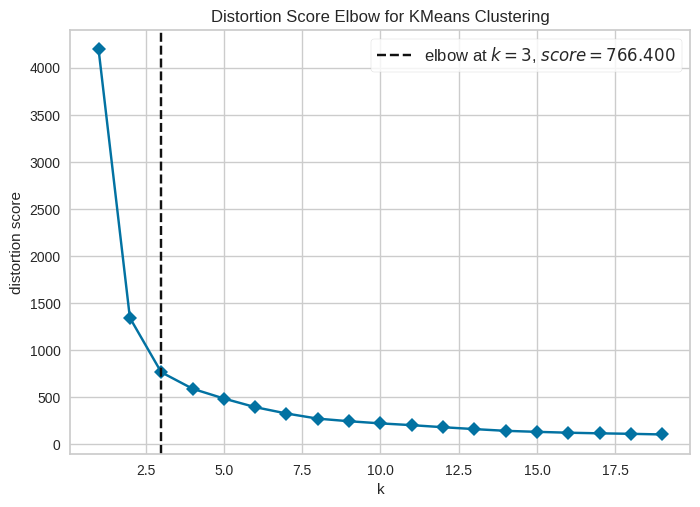

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [158]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import SilhouetteVisualizer

model = KMeans(
    init="k-means++",
    n_init=10,
    max_iter=500,
    random_state=42
)

visualizer = KElbowVisualizer(
    model,
    k=(1, 20),
    metric="distortion",
    timings=False
)

visualizer.fit(embeddings_science_umap)
visualizer.show()

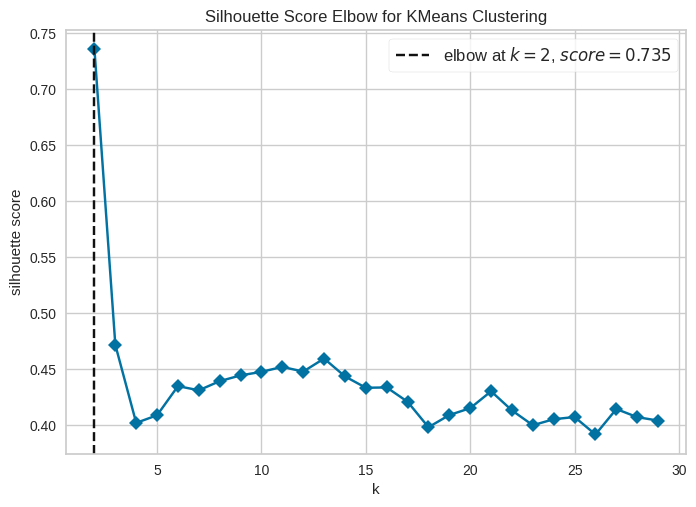

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [159]:
visualizer = KElbowVisualizer(
    model,
    k=(2, 30),
    metric="silhouette",
    timings=False,
    random_state=42
)

visualizer.fit(embeddings_science_umap)
visualizer.show()

### **K-Means Clustering Hypertuning**

n_clusters value were chosen based on local maximums seem on silhoutte score visualization.

In [170]:
import umap
import hdbscan
import numpy as np
from sklearn.metrics import silhouette_score

n_neighbors_values = [5, 8, 10, 15]
n_components_values = [5, 8, 10]
n_clusters_values = [3, 6, 10, 11, 12, 13]

In [171]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score


k_means_results = []

for n_neighbors in n_neighbors_values:
    for n_components in n_components_values:

        umap_model = umap.UMAP(
            n_neighbors=n_neighbors,
            n_components=n_components,
            min_dist=0.0,
            metric='cosine',
            random_state=42
        )

        reduced = umap_model.fit_transform(embeddings_science)

        for n_clusters in n_clusters_values:

                clusterer = KMeans(
                   n_clusters=n_clusters,
                   init="k-means++",
                   n_init=10,
                   max_iter=500,
                   random_state=42
                )

                labels_kmeans = clusterer.fit_predict(reduced)

                silhouette = silhouette_score(
                    reduced,
                    labels_kmeans
                )

                db_k_means = davies_bouldin_score(reduced, labels_kmeans)

                ch_k_means = calinski_harabasz_score(reduced, labels_kmeans)

                k_means_results.append({
                    "n_neighbors": n_neighbors,
                    "n_components": n_components,
                    "n_clusters": n_clusters,
                    "silhouette": silhouette,
                    "davies_bouldin": db_k_means,
                    "calinski_harabasz": ch_k_means
                })

### **HDBSCAN Clustering**

In [ ]:
!pip install hdbscan --quiet

In [162]:
import umap
import hdbscan
import numpy as np
from sklearn.metrics import silhouette_score

n_neighbors_values = [5, 8, 10, 15]
n_components_values = [5, 8, 10]
min_cluster_size_values = [5, 8, 12, 15]
min_samples_values = [2, 3, 5]


In [163]:
dbscan_results = []

for n_neighbors in n_neighbors_values:
    for n_components in n_components_values:

        umap_model = umap.UMAP(
            n_neighbors=n_neighbors,
            n_components=n_components,
            min_dist=0.0,
            metric='cosine',
            random_state=42
        )

        reduced = umap_model.fit_transform(embeddings_science)

        for min_cluster_size in min_cluster_size_values:
            for min_samples in min_samples_values:

                clusterer = hdbscan.HDBSCAN(
                    min_cluster_size=min_cluster_size,
                    min_samples=min_samples,
                    metric='euclidean',
                    cluster_selection_method='leaf'
                )

                labels_hdbscan = clusterer.fit_predict(reduced)

                # Skip if only 1 cluster
                num_clusters = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)

                if num_clusters < 3:
                    continue

                # Skip if too many clusters
                if num_clusters > 50:
                    continue

                # Remove noise points for silhouette score
                mask = labels_hdbscan != -1

                if len(set(labels_hdbscan[mask])) < 2:
                    continue

                silhouette = silhouette_score(
                    reduced[mask],
                    labels_hdbscan[mask]
                )

                noise_pct = np.mean(labels_hdbscan == -1)

                persistence = np.mean(clusterer.cluster_persistence_)

                db_hdbscan = davies_bouldin_score(reduced[mask], labels_hdbscan[mask])

                ch_hdbscan = calinski_harabasz_score(reduced[mask], labels_hdbscan[mask])

                dbscan_results.append({
                    "n_neighbors": n_neighbors,
                    "n_components": n_components,
                    "min_cluster_size": min_cluster_size,
                    "min_samples": min_samples,
                    "num_clusters": num_clusters,
                    "silhouette": silhouette,
                    "noise_pct": noise_pct,
                    "persistence": persistence,
                    "davies_bouldin": db_hdbscan,
                    "calinski_harabasz": ch_hdbscan
                })


### **Model Comparision**

In [164]:
dbscan_results_df = pd.DataFrame(dbscan_results)

dbscan_results_df_filtered = dbscan_results_df[(dbscan_results_df['silhouette'] > 0.40) & (dbscan_results_df['persistence'] > 0.27) & (dbscan_results_df['noise_pct'].between(0.05, 0.35))]

dbscan_results_df_filtered

,n_neighbors,n_components,min_cluster_size,min_samples,num_clusters,silhouette,noise_pct,persistence,davies_bouldin,calinski_harabasz
9,5,5,15,2,12,0.588762,0.165548,0.327418,0.603705,1615.189941
10,5,5,15,3,11,0.641491,0.246085,0.343087,0.483615,1891.035889
11,5,5,15,5,10,0.571687,0.154362,0.318704,0.584507,1106.475098
34,5,10,15,3,11,0.544090,0.147651,0.333394,0.669469,1264.305054
35,5,10,15,5,11,0.574366,0.176734,0.271871,0.583479,1048.024414


In [172]:
k_means_results_df = pd.DataFrame(k_means_results)

k_means_results_df_filtered = k_means_results_df[(k_means_results_df['silhouette'] > 0.55) & (k_means_results_df['davies_bouldin'] < 0.5) & (k_means_results_df['calinski_harabasz'] > 1000)]

k_means_results_df_filtered.sort_values(by=['silhouette', 'davies_bouldin'], ascending=[False, True])

,n_neighbors,n_components,n_clusters,silhouette,davies_bouldin,calinski_harabasz
5,5,5,13,0.585874,0.430516,1329.471924
11,5,8,13,0.581136,0.443219,1311.273438
4,5,5,12,0.576450,0.436486,1167.658569
15,5,10,11,0.575881,0.428465,1239.113525
10,5,8,12,0.572884,0.494898,1245.073975
9,5,8,11,0.569253,0.436160,1092.311035
3,5,5,11,0.568273,0.459642,1015.283630
16,5,10,12,0.553268,0.448117,1279.267944


**DBSCAN Best Model** *(11 clusters)*

Hyperparameters:
- n_neighbors: 5
- n_componenets: 5
- min_cluster_size: 15
- min_samples: 3

Scores:
- Silhouette: 0.641 --> strong
- Noise percentage: 24.6% --> moderate but acceptable
- Persistence: 0.343 --> moderate but stable
- Davies Bouldin: 0.4836 --> compact clusters
- Calinski Harabasz: 1891.04 --> very strong dispersion (can reward artificial splitting of continuous themes)


**Best K-Means Model:** *(13 clusters)*
Hyperparameters:
- n_neighbors: 5
- n_componenets: 5
- n_clusters: 13

Scores:
- Silhouette: 0.585874
- Davies Bouldin: 0.4305
- Calinski Harabasz: 1329.47

**I will use the best DBSCAN model for this analysis.**

### **Best Model**

In [173]:
umap_model = umap.UMAP(
    n_components=5,
    n_neighbors=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

embeddings_science_umap = umap_model.fit_transform(embeddings_science)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

science_labels = hdbscan_model.fit_predict(embeddings_science_umap)

In [174]:
details_science["cluster"] = science_labels

/tmp/ipython-input-262291225.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



### **Extracting Text for Cluster Labels**

**M4 Updates:**
Additional stop words and phrases were identified on a per-category basis to help limit the key word identification to informative and clear key words.

*No additional stop words needed for this category*

In [175]:
# Build cluster documents
science_cluster_docs = (
    details_science[details_science["cluster"] != -1]
    .groupby("cluster")["cleaned_description"]
    .apply(lambda x: " ".join(x))
)

In [176]:
# remove common phrases
PHRASE_STOPWORDS = [
    "funding opportunity",
    "funding opportunity announcement",
    "award mechanism",
    "notice of funding opportunity",
]

def remove_phrases(text):
    text = text.lower()
    for p in PHRASE_STOPWORDS:
        text = text.replace(p, " ")
    return text

science_cluster_docs = science_cluster_docs.apply(remove_phrases)

In [182]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

def extract_cluster_keywords(cluster_series, top_n=6):

    vec = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,2),
        min_df=2,
        max_df=0.6,
        sublinear_tf=True
    )

    X = vec.fit_transform(cluster_series.values)

    terms = np.array(vec.get_feature_names_out())

    results = {}

    for i, cid in enumerate(cluster_series.index):
        scores = X[i].toarray().ravel()
        top_terms = terms[scores.argsort()[-top_n:][::-1]]
        results[cid] = top_terms.tolist()

    return results

science_keywords  = extract_cluster_keywords(science_cluster_docs)


In [183]:
def keywords_to_df(keyword_dict):
    return (
        pd.DataFrame.from_dict(keyword_dict, orient="index")
        .reset_index()
        .rename(columns={"index":"cluster"})
    )

science_keywords_df  = keywords_to_df(science_keywords)

In [184]:
science_keywords_df

,cluster,0,1,2,3,4,5
0,0,roses,program element,program elements,nra,download,science division
1,1,dms,mathematical sciences,50 000,months advance,conferences workshops,mathematical
2,2,trials,clinical trials,clinical,refer,regulatory,care
3,3,roses,program elements,nra,army,program element,nasa
4,4,atmospheric,geoscience,native,fellowship,ear,fellowships
5,5,ci,cps,cybersecurity,privacy,cise,directorates divisions
6,6,onr,naval,defense,baa,dod,college university
7,7,stem education,stem,agep,mid scale,teaching,source
8,8,goali,organismal,biodiversity,cbet,recent awards,discussed program
9,9,transport,cbet,goali,catalysis,reaction,thermal


In [193]:
cluster_label_map = {
    0: "NASA ROSES Space Science Research Programs",
    1: "Mathematical Sciences Research & Conferences",
    2: "Clinical & Translational Health Research",
    3: "Defense & Aerospace Research Programs",
    4: "Atmospheric & Geosciences Research Fellowships",
    5: "Cybersecurity & Privacy Research",
    6: "Naval & Defense Basic Research",
    7: "STEM Education & Workforce Development Programs",
    8: "Organismal Biology & Industry Partnerships",
    9: "Chemical Engineering & Catalysis Research"
}

details_science["cluster_label"] = details_science["cluster"].map(cluster_label_map)

details_science["cluster_label"] = (
    details_science["cluster_label"]
    .fillna("Noise / Unassigned")
)


/tmp/ipython-input-3473677347.py:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-3473677347.py:16: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



**Analysis**

The clusters identified in M4 are more specific than the clusters identified in M3. There are now 9 clusters instead of 7, and do not include outlier grants. They mostly capture the same topics identified previously, with some topics split up.

### **Cluster Analysis**

In [194]:
science_cluster_summary = (
    details_science.groupby("cluster_label").agg(
        n_opps=('opportunity_id', 'count'),
        avg_funding=('estimated_total_program_funding', 'mean'),
        med_funding=('estimated_total_program_funding', 'median'),
        total_funding=('estimated_total_program_funding', 'sum'),
        avg_awards=('expected_number_of_awards', 'mean'),
        med_awards=('expected_number_of_awards', 'median')
    )
    .sort_values("total_funding", ascending=False)
)

science_cluster_summary

,n_opps,avg_funding,med_funding,total_funding,avg_awards,med_awards
cluster_label,,,,,,
Defense & Aerospace Research Programs,38,6.833688e+08,15000000.0,5.466950e+09,71944.714286,550.0
STEM Education & Workforce Development Programs,66,3.470983e+07,20000000.0,2.117300e+09,63.977778,32.0
Noise / Unassigned,78,2.533600e+07,6000000.0,1.140120e+09,30.656250,29.0
Organismal Biology & Industry Partnerships,66,1.926013e+07,10400000.0,8.859660e+08,29.718750,19.0
Chemical Engineering & Catalysis Research,37,2.481322e+07,8000000.0,6.699570e+08,155.416667,15.0
Cybersecurity & Privacy Research,19,4.270000e+07,24000000.0,6.405000e+08,84.888889,20.0
Atmospheric & Geosciences Research Fellowships,26,1.727572e+07,7000000.0,3.627901e+08,24.076923,15.0
Clinical & Translational Health Research,55,7.136093e+06,3840000.0,3.068520e+08,6.022727,3.0
Mathematical Sciences Research & Conferences,19,8.954615e+06,5000000.0,1.164100e+08,26.000000,13.0


**Analysis**

The top 3 sub-domains in the science category are STEM Education & Workforce Development Programs	(66 grants), Organismal Biology & Industry Partnerships (66 grants),
and Clinical & Translational Health Research (55 grants).

The sub-domains with the highest total funding are Defense & Aerospace research programs, STEM education, and Organismal Biology.

Defense & Areospace also the highest average funding and largest mean and median awards, making it the clear dominator of this category.

#### **Funding Concentration**

In [195]:
science_df = science_cluster_summary.reset_index()

In [198]:
funding_threshold = science_df["total_funding"].median()
grant_threshold = science_df["n_opps"].median()

def classify_quadrant(row):
    funding_level = "High Funding" if row["total_funding"] >= funding_threshold else "Low Funding"
    grant_level = "Many Grants" if row["n_opps"] >= grant_threshold else "Few Grants"
    return f"{funding_level} & {grant_level}"

science_df["quadrant"] = science_df.apply(classify_quadrant, axis=1)

matrix = (
    science_df
    .groupby("quadrant")["cluster_label"]
    .apply(list)
    .reindex([
        "High Funding & Few Grants",
        "High Funding & Many Grants",
        "Low Funding & Few Grants",
        "Low Funding & Many Grants"
    ])
)

matrix_df = pd.DataFrame(matrix)
matrix_df.reset_index(inplace=True)
matrix_df

,quadrant,cluster_label
0,High Funding & Few Grants,[Cybersecurity & Privacy Research]
1,High Funding & Many Grants,"[Defense & Aerospace Research Programs, STEM E..."
2,Low Funding & Few Grants,[Atmospheric & Geosciences Research Fellowship...
3,Low Funding & Many Grants,[Clinical & Translational Health Research]


**Analysis**

The Sub-Category with high funding and few grants, indicating large concentrated programs, is cybersecurity & privacy research.

Areas with high funding and many grants, indicating broad strategic priority areas are defense & aerospace, STEM education, organismal biology, and chemical engineering

Areas with low funding and few grants, signaling underserved niche areas, are atmospheric & geosciences research, mathematical sciences, Naval Basic research, and NASA Roses programs.

The Area with low funding and many grants, indicating highly compettive grants, is clinical & translational health research.

In [199]:
funding_threshold = science_df["total_funding"].median()
grant_threshold = science_df["avg_awards"].median()

def classify_quadrant(row):
    funding_level = "High Funding" if row["total_funding"] >= funding_threshold else "Low Funding"
    grant_level = "Many Awards" if row["avg_awards"] >= grant_threshold else "Few Awards"
    return f"{funding_level} & {grant_level}"

science_df["quadrant"] = science_df.apply(classify_quadrant, axis=1)

matrix = (
    science_df
    .groupby("quadrant")["cluster_label"]
    .apply(list)
    .reindex([
        "High Funding & Few Awards",
        "High Funding & Many Awards",
        "Low Funding & Few Awards",
        "Low Funding & Many Awards"
    ])
)

matrix_df = pd.DataFrame(matrix)
matrix_df.reset_index(inplace=True)
matrix_df

,quadrant,cluster_label
0,High Funding & Few Awards,"[Noise / Unassigned, Organismal Biology & Indu..."
1,High Funding & Many Awards,"[Defense & Aerospace Research Programs, STEM E..."
2,Low Funding & Few Awards,[Atmospheric & Geosciences Research Fellowship...
3,Low Funding & Many Awards,[Naval & Defense Basic Research]


**Analysis**

When looking at average awards instead of the number of grants, there are a key key changes. Organismal biology moved from high funding many grants to High funding & few awards, Cybersecurity had few grants but many awards (still high funding). Defense & Aerospace, STEM education, and Chemical engineering have many awards and many grants.
Low funding & few awards is similar to low funding & few grants, but now captures clinical health research and no longer captures naval and defense basic research.
Low funding & many awards only captures naval and defense basic research.


## **Education Category Clustering**

### **Creating Education DataFrame**

In [200]:
details_education = details[details['official_category'] == 'education']
details_education.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,442.000000,18.000000,442.000000,442,442,434,435,423,2.000000e+01,1.890000e+02,1.900000e+01
mean,338355.038462,7.055556,1.282805,2022-04-03 03:38:16.832579328,2022-07-21 07:52:23.891402752,2024-09-02 15:35:40.092165888,2024-12-24 05:11:10.344827648,2025-03-15 09:14:53.617021440,2.533998e+08,2.012663e+06,1.419737e+06
min,49325.000000,1.000000,1.000000,2009-09-02 00:00:00,2011-04-27 00:00:00,2009-07-29 00:00:00,2009-07-29 00:00:00,2023-10-29 00:00:00,2.000000e+04,0.000000e+00,0.000000e+00
25%,335476.000000,1.000000,1.000000,2021-08-27 06:00:00,2021-12-10 18:00:00,2023-12-11 00:00:00,2024-02-01 00:00:00,2024-03-22 00:00:00,1.000000e+07,2.750000e+05,0.000000e+00
50%,342972.500000,1.000000,1.000000,2022-08-06 00:00:00,2022-12-10 00:00:00,2024-09-07 00:00:00,2024-09-07 00:00:00,2024-10-13 00:00:00,2.312500e+07,3.500000e+05,2.500000e+04
75%,348039.000000,5.750000,1.000000,2023-05-09 12:00:00,2023-05-23 00:00:00,2025-06-08 06:00:00,2025-06-17 00:00:00,2025-08-09 12:00:00,5.500000e+07,5.000000e+05,1.000000e+06
max,350389.000000,52.000000,18.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2028-02-08 00:00:00,2121-10-12 00:00:00,2121-11-11 00:00:00,4.350000e+09,6.000000e+07,1.000000e+07
std,24675.063168,12.581369,1.104156,NaN,NaN,NaN,NaN,NaN,9.650793e+08,7.345700e+06,2.944446e+06


### **Text Embedding**

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("BAAI/bge-large-en-v1.5")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [201]:
details_education["description_chunks"] = details_education["description_chunks"].apply(
    lambda chunks: [
        "Represent this sentence for clustering: " + chunk
        for chunk in chunks
    ]
)

# Average embeddings across chunks
details_education["embedding"] = details_education["description_chunks"].apply(
    lambda chunks: np.mean(
        embedding_model.encode(
            chunks,
            batch_size=64,
            normalize_embeddings=True,
            convert_to_numpy=True
        ),
        axis=0
    ).astype(np.float32)
)

embeddings_education = np.vstack(details_education["embedding"].values)

/tmp/ipython-input-2446217733.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-2446217733.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



###**K-Means Elbow Test** (identifying hyperparameters to test)

In [202]:
import umap

umap_model = umap.UMAP(
    n_components=15,
    n_neighbors=15,
    metric='cosine',
    random_state=42
)

embeddings_education_umap = umap_model.fit_transform(embeddings_education)

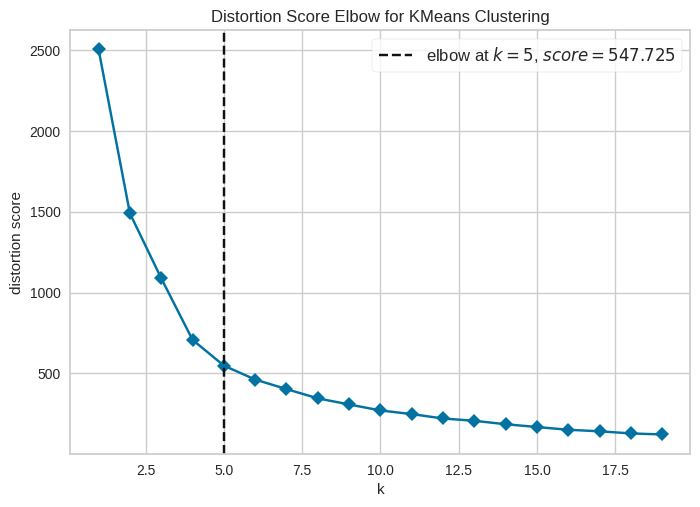

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [203]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import SilhouetteVisualizer

model = KMeans(
    init="k-means++",
    n_init=10,
    max_iter=500,
    random_state=42
)

visualizer = KElbowVisualizer(
    model,
    k=(1, 20),
    metric="distortion",
    timings=False
)

visualizer.fit(embeddings_education_umap)
visualizer.show()

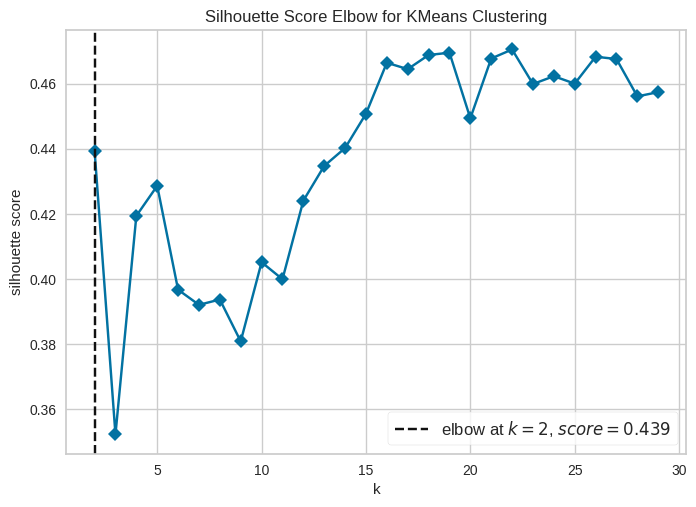

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [204]:
visualizer = KElbowVisualizer(
    model,
    k=(2, 30),
    metric="silhouette",
    timings=False,
    random_state=42
)

visualizer.fit(embeddings_education_umap)
visualizer.show()

### **K-Means Clustering Hypertuning**

n_clusters value were chosen based on local maximums seem on silhoutte score visualization.

In [205]:
import umap
import hdbscan
import numpy as np
from sklearn.metrics import silhouette_score

n_neighbors_values = [5, 8, 10, 15]
n_components_values = [5, 8, 10]
n_clusters_values = [5, 10, 16, 19, 22]

In [206]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score


k_means_results = []

for n_neighbors in n_neighbors_values:
    for n_components in n_components_values:

        umap_model = umap.UMAP(
            n_neighbors=n_neighbors,
            n_components=n_components,
            min_dist=0.0,
            metric='cosine',
            random_state=42
        )

        reduced = umap_model.fit_transform(embeddings_education)

        for n_clusters in n_clusters_values:

                clusterer = KMeans(
                   n_clusters=n_clusters,
                   init="k-means++",
                   n_init=10,
                   max_iter=500,
                   random_state=42
                )

                labels_kmeans = clusterer.fit_predict(reduced)

                silhouette = silhouette_score(
                    reduced,
                    labels_kmeans
                )

                db_k_means = davies_bouldin_score(reduced, labels_kmeans)

                ch_k_means = calinski_harabasz_score(reduced, labels_kmeans)

                k_means_results.append({
                    "n_neighbors": n_neighbors,
                    "n_components": n_components,
                    "n_clusters": n_clusters,
                    "silhouette": silhouette,
                    "davies_bouldin": db_k_means,
                    "calinski_harabasz": ch_k_means
                })

### **HDBSCAN Clustering**

In [ ]:
!pip install hdbscan --quiet

In [207]:
import umap
import hdbscan
import numpy as np
from sklearn.metrics import silhouette_score

n_neighbors_values = [5, 8, 10, 15]
n_components_values = [5, 8, 10]
min_cluster_size_values = [5, 8, 12, 15]
min_samples_values = [2, 3, 5]


In [235]:
dbscan_results = []

for n_neighbors in n_neighbors_values:
    for n_components in n_components_values:

        umap_model = umap.UMAP(
            n_neighbors=n_neighbors,
            n_components=n_components,
            min_dist=0.0,
            metric='cosine',
            random_state=42
        )

        reduced = umap_model.fit_transform(embeddings_education)

        for min_cluster_size in min_cluster_size_values:
            for min_samples in min_samples_values:

                clusterer = hdbscan.HDBSCAN(
                    min_cluster_size=min_cluster_size,
                    min_samples=min_samples,
                    metric='euclidean',
                    cluster_selection_method='eom'
                )

                labels_hdbscan = clusterer.fit_predict(reduced)

                # Skip if only 1 cluster
                num_clusters = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)

                if num_clusters < 3:
                    continue

                # Skip if too many clusters
                if num_clusters > 50:
                    continue

                # Remove noise points for silhouette score
                mask = labels_hdbscan != -1

                if len(set(labels_hdbscan[mask])) < 2:
                    continue

                silhouette = silhouette_score(
                    reduced[mask],
                    labels_hdbscan[mask]
                )

                noise_pct = np.mean(labels_hdbscan == -1)

                persistence = np.mean(clusterer.cluster_persistence_)

                db_hdbscan = davies_bouldin_score(reduced[mask], labels_hdbscan[mask])

                ch_hdbscan = calinski_harabasz_score(reduced[mask], labels_hdbscan[mask])

                dbscan_results.append({
                    "n_neighbors": n_neighbors,
                    "n_components": n_components,
                    "min_cluster_size": min_cluster_size,
                    "min_samples": min_samples,
                    "num_clusters": num_clusters,
                    "silhouette": silhouette,
                    "noise_pct": noise_pct,
                    "persistence": persistence,
                    "davies_bouldin": db_hdbscan,
                    "calinski_harabasz": ch_hdbscan
                })


### **Model Comparision**

In [236]:
dbscan_results_df = pd.DataFrame(dbscan_results)

dbscan_results_df_filtered = dbscan_results_df[(dbscan_results_df['silhouette'] > 0.6) & (dbscan_results_df['persistence'] > 0.28) & (dbscan_results_df['noise_pct'].between(0.05, 0.35))]

dbscan_results_df_filtered.sort_values(by=['silhouette', 'persistence'], ascending=[False, False])

,n_neighbors,n_components,min_cluster_size,min_samples,num_clusters,silhouette,noise_pct,persistence,davies_bouldin,calinski_harabasz
5,5,5,8,5,24,0.683843,0.142534,0.293335,0.442576,1810.008179
7,5,5,12,3,18,0.650535,0.169683,0.286186,0.494302,1308.630493
6,5,5,12,2,18,0.647174,0.165158,0.314973,0.500542,1308.869019
29,5,10,8,5,22,0.628383,0.149321,0.282768,0.503595,431.069427
28,5,10,8,3,26,0.609555,0.070136,0.285040,0.588231,447.616302


In [220]:
k_means_results_df = pd.DataFrame(k_means_results)

k_means_results_df_filtered = k_means_results_df[(k_means_results_df['silhouette'] > 0.58) & (k_means_results_df['davies_bouldin'] < 0.6) & (k_means_results_df['calinski_harabasz'] > 800)]

k_means_results_df_filtered.sort_values(by=['silhouette', 'davies_bouldin'], ascending=[False, True])

,n_neighbors,n_components,n_clusters,silhouette,davies_bouldin,calinski_harabasz
4,5,5,22,0.603207,0.531517,1585.662720
3,5,5,19,0.588983,0.533798,1292.428955
14,5,10,22,0.586184,0.556218,1334.911743
9,5,8,22,0.580765,0.535417,1451.526489


**DBSCAN Best Model** *(18 clusters, preferable to 24 clusters)*

Hyperparameters:
- n_neighbors: 5
- n_componenets: 5
- min_cluster_size: 12
- min_samples: 3

Scores:
- Silhouette: 0.65 --> strong
- Noise percentage: 16.9% --> moderate but acceptable
- Persistence: 0.286 --> moderate but stable
- Davies Bouldin: 0.494 --> compact clusters
- Calinski Harabasz: 1308 --> strong dispersion


**Best K-Means Model:** *(22 clusters)*
Hyperparameters:
- n_neighbors: 5
- n_componenets: 5
- n_clusters: 22

**I will use the best DBSCAN model for this analysis.**

### **Best Model**

In [237]:
umap_model = umap.UMAP(
    n_components=5,
    n_neighbors=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

embeddings_education_umap = umap_model.fit_transform(embeddings_education)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=12,
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

education_labels = hdbscan_model.fit_predict(embeddings_education_umap)

In [238]:
details_education["cluster"] = education_labels

/tmp/ipython-input-3358709291.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



### **Extracting Text for Cluster Labels**

**M4 Updates:**
Additional stop words and phrases were identified on a per-category basis to help limit the key word identification to informative and clear key words.

*No additional stop words needed for this category*

In [239]:
# Build cluster documents
education_cluster_docs = (
    details_education[details_education["cluster"] != -1]
    .groupby("cluster")["cleaned_description"]
    .apply(lambda x: " ".join(x))
)

In [240]:
# remove common phrases
PHRASE_STOPWORDS = [
    "funding opportunity",
    "funding opportunity announcement",
    "award mechanism",
    "notice of funding opportunity",
]

def remove_phrases(text):
    text = text.lower()
    for p in PHRASE_STOPWORDS:
        text = text.replace(p, " ")
    return text

education_cluster_docs = education_cluster_docs.apply(remove_phrases)

In [241]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

def extract_cluster_keywords(cluster_series, top_n=6):

    vec = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,2),
        min_df=2,
        max_df=0.6,
        sublinear_tf=True
    )

    X = vec.fit_transform(cluster_series.values)

    terms = np.array(vec.get_feature_names_out())

    results = {}

    for i, cid in enumerate(cluster_series.index):
        scores = X[i].toarray().ravel()
        top_terms = terms[scores.argsort()[-top_n:][::-1]]
        results[cid] = top_terms.tolist()

    return results

education_keywords  = extract_cluster_keywords(education_cluster_docs)


In [242]:
def keywords_to_df(keyword_dict):
    return (
        pd.DataFrame.from_dict(keyword_dict, orient="index")
        .reset_index()
        .rename(columns={"index":"cluster"})
    )

education_keywords_df  = keywords_to_df(education_keywords)

In [243]:
education_keywords_df

,cluster,0,1,2,3,4,5
0,0,purpose nih,support protected,ancillary clinical,doctoral degree,patient oriented,oriented research
1,1,education,federal,published,document,msis,note
2,2,pain,pain conditions,heal,device,heal initiative,devices
3,3,brain cell,brain,compounds,brain initiative,cell,chemical
4,4,circuit,circuits,recording,species,neural,manipulation
5,5,educational,education,mission areas,accomplish,undergraduate,support creative
6,6,aud,alcohol,opioid,purpose nofo,oud,overdose
7,7,markers,biospecimens,assays,path,assay,biomarkers
8,8,aids research,hiv,aids,hiv research,racial,hiv aids
9,9,sud,aids,hiv aids,suds,use disorders,disorders suds


In [244]:
cluster_label_map = {
    0: "Career Development Research (Patient-Oriented)",
    1: "Federal Education Program Administration & Announcements",
    2: "HEAL Initiative – Pain & Addiction Workforce Training",
    3: "BRAIN Initiative – Neuroscience Training Programs",
    4: "Neurotechnology & Systems Neuroscience Training",
    5: "Undergraduate Education Programs",
    6: "Addiction & Substance Use Research Training Programs",
    7: "Translational Biomarker & Clinical Methods Training",
    8: "HIV/AIDS Research Education & Health Disparities Training",
    9: "Substance Use & HIV Integrated Training Programs",
    10: "Cancer Informatics & Data Science Training",
    11: "Cancer Biology & Data Integration Training Programs",
    12: "Human Subjects & Clinical Research Methods Education",
    13: "Substance Use Treatment & Services Workforce",
    14: "Entrepreneurship & Small Business Research Training",
    15: "Cancer Immunology & Oncology Research Training",
    16: "Dissemination & Implementation Science Training",
    17: "Faculty Development & Institutional Workforce Support"
}

details_education["cluster_label"] = details_education["cluster"].map(cluster_label_map)

details_education["cluster_label"] = (
    details_education["cluster_label"]
    .fillna("Noise / Unassigned")
)


/tmp/ipython-input-441854439.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-441854439.py:24: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



**Analysis**

The clusters identified in M4 are much more specific than the clusters identified in M3. There are now 18 clusters instead 6, and although there are some overlapping themes, these better highlight the actual sub-domain rather than some of the vague "catch all" categories in M3.

###**Cluster Analysis**

In [249]:
education_cluster_summary = (
    details_education.groupby("cluster_label").agg(
        n_opps=('opportunity_id', 'count'),
        avg_funding=('estimated_total_program_funding', 'mean'),
        med_funding=('estimated_total_program_funding', 'median'),
        total_funding=('estimated_total_program_funding', 'sum'),
        avg_awards=('expected_number_of_awards', 'mean'),
        med_awards=('expected_number_of_awards', 'median')
    )
    .sort_values("total_funding", ascending=False)
)

education_cluster_summary['n_opps'].sort_values(ascending=False)

,n_opps
cluster_label,
Noise / Unassigned,75
Faculty Development & Institutional Workforce Support,38
Career Development Research (Patient-Oriented),31
Federal Education Program Administration & Announcements,29
Undergraduate Education Programs,26
Human Subjects & Clinical Research Methods Education,25
Dissemination & Implementation Science Training,22
Cancer Immunology & Oncology Research Training,21
HEAL Initiative – Pain & Addiction Workforce Training,20


While noise occupies the largest cluster, the top 5 education sub-domains are around career development, federal education programs, undergraduate education programs, and clinical research education.

Overall, these granular clusters could be grouped in larger clusters to create a hierarchy, such as:  
- Career/Workforce Development
- Cancer
- Substance Use & Addiction
- Neuroscience

They can also be grouped into Discovery or Implementation, i.e. whether they focus on knowledge generation or knowledge deployment.

In [250]:
education_cluster_summary[~education_cluster_summary['avg_funding'].isna()].sort_values(by='total_funding', ascending=False)

,n_opps,avg_funding,med_funding,total_funding,avg_awards,med_awards
cluster_label,,,,,,
Federal Education Program Administration & Announcements,29,3.134997e+08,33000000.0,5.015996e+09,7.5625,1.0
Neurotechnology & Systems Neuroscience Training,15,2.200000e+07,22000000.0,2.200000e+07,5.0000,5.0
HEAL Initiative – Pain & Addiction Workforce Training,20,1.000000e+07,10000000.0,2.000000e+07,NaN,NaN
Dissemination & Implementation Science Training,22,1.000000e+07,10000000.0,1.000000e+07,1.0000,1.0


Many of the grants in this section are missing estimated funding data, but out of the sub-domains with adequate data, Federal Education Program Administration dominates average funding, total funding, and average awards.

#### **Discovery vs Implementation Grants**

In [258]:
# Define discovery vs implementation term sets
DISCOVERY_TERMS = {
    # Basic/experimental science + computational discovery
    "molecular", "cell", "cells", "cellular", "mechanism", "mechanisms",
    "pathway", "pathways", "genome", "genomic", "genomics", "sequencing",
    "biomarker", "biomarkers", "biospecimen", "biospecimens", "assay", "assays",
    "neural", "neuroscience", "brain", "circuit", "circuits", "electrophysiology",
    "compound", "compounds", "chemical", "chemistry", "metabolism", "metabolic",
    "tumor", "tumors", "oncology", "immune", "immunology", "microbial", "microbiome",
    "mouse", "mammalian", "in vivo", "in vitro",
    "informatics", "computational", "modeling", "simulation", "ontology", "algorithm",
    "data science", "machine learning"
}

IMPLEMENTATION_TERMS = {
    # Delivery/system/practice/D&I + workforce and programmatic education
    "implementation", "dissemination", "implementation science", "dissemination and implementation",
    "services", "service delivery", "delivery", "practice", "clinical care", "care", "care coordination",
    "community", "community-based", "population", "public health",
    "health disparities", "disparities", "equity", "racial", "underserved", "access",
    "adherence", "uptake", "barriers", "facilitators", "feasibility", "acceptability",
    "intervention", "interventions", "prevention", "screening", "program", "programs",
    "workforce", "training", "education", "teaching", "curriculum", "mentoring",
    "faculty", "recruitment", "salary", "position",
    "policy", "regulatory", "guidelines", "quality improvement"
}


# Text normalization helper (inline)
def normalize_text(text: str) -> str:
    text = str(text).lower()
    # Normalize some common grant formatting artifacts
    text = text.replace("d&i", "dissemination and implementation")
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Scoring function using full cluster text
def score_text(text: str, term_set: set) -> int:
    score = 0
    words = set(re.findall(r"\b[a-z0-9]+\b", text))
    for term in term_set:
        if " " in term:
            if term in text:
                score += 2
        else:
            if term in words:
                score += 1
    return score


# Classify each cluster (Discovery / Implementation / Mixed)
MARGIN = 5  # increase to be stricter, decrease to label fewer as Mixed

rows = []
for cid, raw_text in education_cluster_docs.items():
    text = normalize_text(raw_text)

    d_score = score_text(text, DISCOVERY_TERMS)
    i_score = score_text(text, IMPLEMENTATION_TERMS)

    if d_score >= i_score + MARGIN:
        ctype = "Discovery"
    elif i_score >= d_score + MARGIN:
        ctype = "Implementation"
    else:
        ctype = "Mixed"

    rows.append({
        "cluster": cid,
        "discovery_score": d_score,
        "implementation_score": i_score,
        "cluster_type": ctype
    })

cluster_type_df = (
    pd.DataFrame(rows)
    .sort_values(["cluster_type", "implementation_score", "discovery_score"], ascending=[True, False, False])
    .reset_index(drop=True)
)

cluster_type_df

,cluster,discovery_score,implementation_score,cluster_type
0,11,22,15,Discovery
1,3,21,11,Discovery
2,15,18,10,Discovery
3,7,17,9,Discovery
4,4,13,8,Discovery
5,13,3,27,Implementation
6,10,10,26,Implementation
7,16,6,23,Implementation
8,17,3,23,Implementation
9,14,5,22,Implementation


In [260]:
# Map back to main df
cluster_type_map = dict(
    zip(cluster_type_df["cluster"], cluster_type_df["cluster_type"])
)

details_education["cluster_type"] = (
    details_education["cluster"]
    .map(cluster_type_map)
    .fillna("Noise / Unassigned")
)

/tmp/ipython-input-2882200589.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



/tmp/ipython-input-2144800549.py:5: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



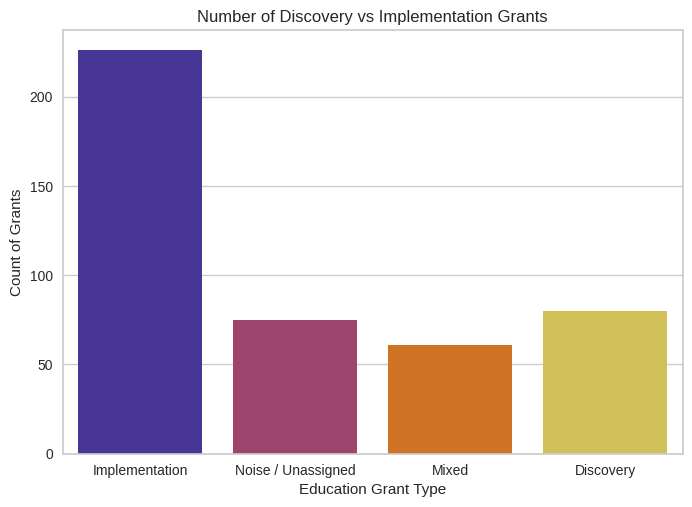

In [267]:
sns.countplot(x='cluster_type', data=details_education, palette="CMRmap")
plt.title('Number of Discovery vs Implementation Grants')
plt.xlabel('Education Grant Type')
plt.ylabel('Count of Grants')

plt.show()

**Analysis**

Implementation type grants dominate the education category, by more than double of mixed or discovery type grants. This means education grants primarily focus on implementing knowledge, such as workforce trainings.

## **Other Category Clustering**

### **Creating Other DataFrame**

In [268]:
details_other = details[details['official_category'] == 'other']
details_other.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,114.000000,63.000000,114.000000,114,114,71,71,46,5.400000e+01,1.050000e+02,1.040000e+02
mean,314469.192982,60.158730,3.307018,2020-10-20 23:47:22.105263104,2021-04-12 06:18:56.842105344,2027-08-16 12:30:25.352112640,2028-02-24 11:49:51.549295872,2024-03-13 15:39:07.826086912,4.336868e+07,1.128512e+07,9.660337e+05
min,40112.000000,0.000000,1.000000,2007-11-28 00:00:00,2007-11-28 00:00:00,2017-12-18 00:00:00,2017-08-13 00:00:00,2023-10-29 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,317601.250000,1.000000,1.000000,2019-07-16 12:00:00,2020-12-27 00:00:00,2023-06-15 12:00:00,2023-09-30 00:00:00,2023-11-18 06:00:00,3.937500e+05,5.000000e+04,0.000000e+00
50%,341915.000000,5.000000,2.000000,2022-07-05 00:00:00,2023-01-30 12:00:00,2023-10-06 00:00:00,2023-11-16 00:00:00,2024-01-16 12:00:00,4.870000e+06,5.000000e+05,3.000000e+03
75%,348591.750000,10.000000,4.750000,2023-06-06 12:00:00,2023-07-23 00:00:00,2023-12-26 12:00:00,2024-03-21 12:00:00,2024-05-08 00:00:00,1.950000e+07,5.000000e+06,2.125000e+05
max,350362.000000,3000.000000,19.000000,2023-09-27 00:00:00,2023-09-28 00:00:00,2099-01-01 00:00:00,2099-01-01 00:00:00,2025-05-26 00:00:00,5.000000e+08,3.749813e+08,3.080000e+07
std,70362.197925,377.072903,3.320964,NaN,NaN,NaN,NaN,NaN,1.098767e+08,4.072138e+07,3.623084e+06


### **Text Embedding**

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("BAAI/bge-large-en-v1.5")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [269]:
details_other["description_chunks"] = details_other["description_chunks"].apply(
    lambda chunks: [
        "Represent this sentence for clustering: " + chunk
        for chunk in chunks
    ]
)

# Average embeddings across chunks
details_other["embedding"] = details_other["description_chunks"].apply(
    lambda chunks: np.mean(
        embedding_model.encode(
            chunks,
            batch_size=64,
            normalize_embeddings=True,
            convert_to_numpy=True
        ),
        axis=0
    ).astype(np.float32)
)

embeddings_other = np.vstack(details_other["embedding"].values)

/tmp/ipython-input-3859962677.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-3859962677.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



###**K-Means Elbow Test** (identifying hyperparameters to test)

In [273]:
import umap

umap_model = umap.UMAP(
    n_components=10,
    n_neighbors=5,
    metric='cosine',
    random_state=42
)

embeddings_other_umap = umap_model.fit_transform(embeddings_other)

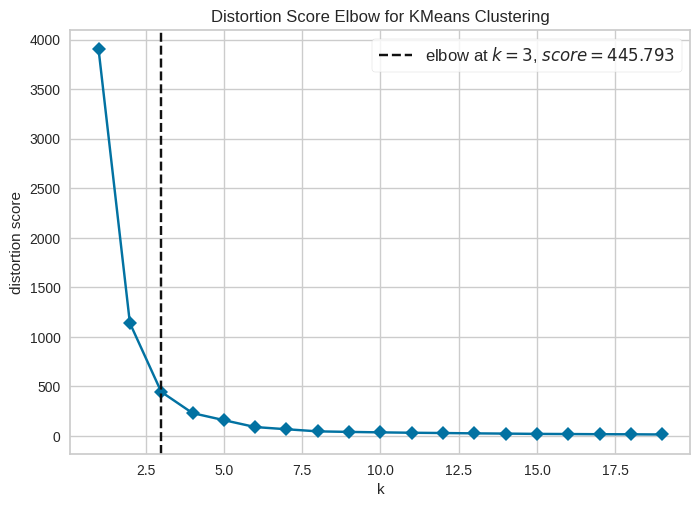

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [274]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import SilhouetteVisualizer

model = KMeans(
    init="k-means++",
    n_init=10,
    max_iter=500,
    random_state=42
)

visualizer = KElbowVisualizer(
    model,
    k=(1, 20),
    metric="distortion",
    timings=False
)

visualizer.fit(embeddings_other_umap)
visualizer.show()

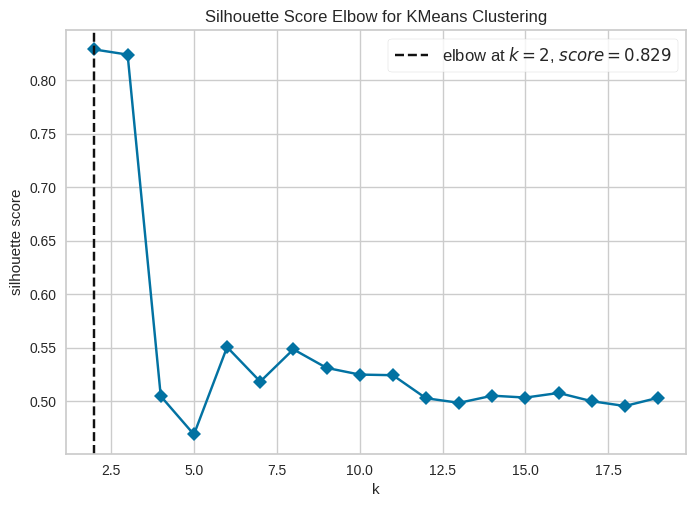

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [275]:
visualizer = KElbowVisualizer(
    model,
    k=(2, 20),
    metric="silhouette",
    timings=False,
    random_state=42
)

visualizer.fit(embeddings_other_umap)
visualizer.show()

### **K-Means Clustering Hypertuning**

n_clusters value were chosen based on local maximums seem on silhoutte score visualization.

In [276]:
import umap
import hdbscan
import numpy as np
from sklearn.metrics import silhouette_score

n_neighbors_values = [5, 8, 10, 12]
n_components_values = [3, 6, 8]
n_clusters_values = [2, 4, 9]

In [277]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score


k_means_results = []

for n_neighbors in n_neighbors_values:
    for n_components in n_components_values:

        umap_model = umap.UMAP(
            n_neighbors=n_neighbors,
            n_components=n_components,
            min_dist=0.0,
            metric='cosine',
            random_state=42
        )

        reduced = umap_model.fit_transform(embeddings_other)

        for n_clusters in n_clusters_values:

                clusterer = KMeans(
                   n_clusters=n_clusters,
                   init="k-means++",
                   n_init=10,
                   max_iter=500,
                   random_state=42
                )

                labels_kmeans = clusterer.fit_predict(reduced)

                silhouette = silhouette_score(
                    reduced,
                    labels_kmeans
                )

                db_k_means = davies_bouldin_score(reduced, labels_kmeans)

                ch_k_means = calinski_harabasz_score(reduced, labels_kmeans)

                k_means_results.append({
                    "n_neighbors": n_neighbors,
                    "n_components": n_components,
                    "n_clusters": n_clusters,
                    "silhouette": silhouette,
                    "davies_bouldin": db_k_means,
                    "calinski_harabasz": ch_k_means
                })

### **HDBSCAN Clustering**

In [ ]:
!pip install hdbscan --quiet

In [278]:
import umap
import hdbscan
import numpy as np
from sklearn.metrics import silhouette_score

n_neighbors_values = [5, 8, 10, 12]
n_components_values = [3, 5, 8]
min_cluster_size_values = [5, 8, 10, 12]
min_samples_values = [2, 3, 5]


In [279]:
dbscan_results = []

for n_neighbors in n_neighbors_values:
    for n_components in n_components_values:

        umap_model = umap.UMAP(
            n_neighbors=n_neighbors,
            n_components=n_components,
            min_dist=0.0,
            metric='cosine',
            random_state=42
        )

        reduced = umap_model.fit_transform(embeddings_other)

        for min_cluster_size in min_cluster_size_values:
            for min_samples in min_samples_values:

                clusterer = hdbscan.HDBSCAN(
                    min_cluster_size=min_cluster_size,
                    min_samples=min_samples,
                    metric='euclidean',
                    cluster_selection_method='eom'
                )

                labels_hdbscan = clusterer.fit_predict(reduced)

                # Skip if only 1 cluster
                num_clusters = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)

                if num_clusters < 3:
                    continue

                # Skip if too many clusters
                if num_clusters > 50:
                    continue

                # Remove noise points for silhouette score
                mask = labels_hdbscan != -1

                if len(set(labels_hdbscan[mask])) < 2:
                    continue

                silhouette = silhouette_score(
                    reduced[mask],
                    labels_hdbscan[mask]
                )

                noise_pct = np.mean(labels_hdbscan == -1)

                persistence = np.mean(clusterer.cluster_persistence_)

                db_hdbscan = davies_bouldin_score(reduced[mask], labels_hdbscan[mask])

                ch_hdbscan = calinski_harabasz_score(reduced[mask], labels_hdbscan[mask])

                dbscan_results.append({
                    "n_neighbors": n_neighbors,
                    "n_components": n_components,
                    "min_cluster_size": min_cluster_size,
                    "min_samples": min_samples,
                    "num_clusters": num_clusters,
                    "silhouette": silhouette,
                    "noise_pct": noise_pct,
                    "persistence": persistence,
                    "davies_bouldin": db_hdbscan,
                    "calinski_harabasz": ch_hdbscan
                })


### **Model Comparision**

In [283]:
dbscan_results_df = pd.DataFrame(dbscan_results)

dbscan_results_df_filtered = dbscan_results_df[(dbscan_results_df['silhouette'] > 0.55) & (dbscan_results_df['persistence'] > 0.35) & (dbscan_results_df['noise_pct'].between(0.05, 0.35))]

dbscan_results_df_filtered.sort_values(by=['silhouette', 'persistence'], ascending=[False, False])

,n_neighbors,n_components,min_cluster_size,min_samples,num_clusters,silhouette,noise_pct,persistence,davies_bouldin,calinski_harabasz
9,5,5,5,5,5,0.586748,0.096491,0.364219,0.491037,739.326477
3,5,3,8,2,5,0.581510,0.087719,0.372370,0.476653,752.408691
11,5,5,8,3,5,0.574959,0.078947,0.468912,0.506285,708.243713
10,5,5,8,2,5,0.574959,0.078947,0.438688,0.506285,708.243713
4,5,3,8,3,6,0.550878,0.122807,0.372076,0.523659,769.223633


In [289]:
k_means_results_df = pd.DataFrame(k_means_results)

k_means_results_df_filtered = k_means_results_df[(k_means_results_df['silhouette'] > 0.45) & (k_means_results_df['davies_bouldin'] < 0.6) & (k_means_results_df['calinski_harabasz'] > 700)]

k_means_results_df_filtered.sort_values(by=['silhouette', 'davies_bouldin'], ascending=[False, True])

,n_neighbors,n_components,n_clusters,silhouette,davies_bouldin,calinski_harabasz
2,5,3,9,0.604159,0.437378,1101.852783
8,5,8,9,0.576796,0.506267,766.198486


**DBSCAN Best Model** *(5 clusters)*

*based on model 11, better persistantance for small decrease in silhouette score*

Hyperparameters:
- n_neighbors: 5
- n_componenets: 5
- min_cluster_size: 8
- min_samples: 3


**Best K-Means Model:** *(9 clusters)*
Hyperparameters:
- n_neighbors: 5
- n_componenets: 3
- n_clusters: 9

**I will use the best DBSCAN model for this analysis.**
While the K-Means model for 9 clusters has a better silhouette score, 5 clusters is more ideal for the number of grants within the 'other' category.

### **Best Model**

In [297]:
umap_model = umap.UMAP(
    n_components=5,
    n_neighbors=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

embeddings_other_umap = umap_model.fit_transform(embeddings_other)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=8,
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

other_labels = hdbscan_model.fit_predict(embeddings_other_umap)

In [298]:
details_other["cluster"] = other_labels

/tmp/ipython-input-118470348.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



### **Extracting Text for Cluster Labels**

In [299]:
# Build cluster documents
other_cluster_docs = (
    details_other[details_other["cluster"] != -1]
    .groupby("cluster")["cleaned_description"]
    .apply(lambda x: " ".join(x))
)

In [300]:
# remove common phrases
PHRASE_STOPWORDS = [
    "funding opportunity",
    "funding opportunity announcement",
    "award mechanism",
    "notice of funding opportunity",
]

def remove_phrases(text):
    text = text.lower()
    for p in PHRASE_STOPWORDS:
        text = text.replace(p, " ")
    return text

other_cluster_docs = other_cluster_docs.apply(remove_phrases)

In [307]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

def extract_cluster_keywords(cluster_series, top_n=10):

    vec = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,2),
        min_df=2,
        max_df=0.6,
        sublinear_tf=True
    )

    X = vec.fit_transform(cluster_series.values)

    terms = np.array(vec.get_feature_names_out())

    results = {}

    for i, cid in enumerate(cluster_series.index):
        scores = X[i].toarray().ravel()
        top_terms = terms[scores.argsort()[-top_n:][::-1]]
        results[cid] = top_terms.tolist()

    return results

other_keywords  = extract_cluster_keywords(other_cluster_docs)


In [308]:
def keywords_to_df(keyword_dict):
    return (
        pd.DataFrame.from_dict(keyword_dict, orient="index")
        .reset_index()
        .rename(columns={"index":"cluster"})
    )

other_keywords_df  = keywords_to_df(other_keywords)

In [309]:
other_keywords_df

,cluster,0,1,2,3,4,5,6,7,8,9
0,0,eda,edge,economic development,partnership planning,platform,experience,planning program,distressed,longer,makes
1,1,entity,eda,local governments,ceds,eligible recipients,partnership planning,state local,economic development,governments,eda provides
2,2,small grants,grants program,mission,human,human rights,rights,small,humanitarian,professional,multilateral
3,3,usaid,aps,addendum,agency,document,solicitation,humanitarian,gaza,questions,tab
4,4,award,embassy,american,federal,budget,section,women,proposals,date,exchange


In [311]:
cluster_label_map = {
    0: "Regional Economic Development & Distressed Community Planning Grants",
    1: "State & Local Economic Development Strategy Grants",
    2: "Human Rights & Multilateral Humanitarian Assistance Grants",
    3: "USAID Humanitarian & Emergency Response Programs",
    4: "U.S. Embassy Public Diplomacy & Women’s Empowerment Grants"
}

details_other["cluster_label"] = details_other["cluster"].map(cluster_label_map)

details_other["cluster_label"] = (
    details_other["cluster_label"]
    .fillna("Noise / Unassigned")
)


/tmp/ipython-input-870799499.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-870799499.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



**Analysis**

The clusters align closely with the sub-topics identified in M3.

### **Cluster Analysis**

In [314]:
other_cluster_summary = (
    details_other.groupby("cluster_label").agg(
        n_opps=('opportunity_id', 'count'),
        avg_funding=('estimated_total_program_funding', 'mean'),
        med_funding=('estimated_total_program_funding', 'median'),
        total_funding=('estimated_total_program_funding', 'sum'),
        avg_awards=('expected_number_of_awards', 'mean'),
        med_awards=('expected_number_of_awards', 'median')
    )
    .sort_values("total_funding", ascending=False)
)

other_cluster_summary.sort_values(by='total_funding', ascending=False)

,n_opps,avg_funding,med_funding,total_funding,avg_awards,med_awards
cluster_label,,,,,,
USAID Humanitarian & Emergency Response Programs,37,5.345714e+07,19000000.0,748400000.0,7.277778,4.0
U.S. Embassy Public Diplomacy & Women’s Empowerment Grants,40,2.792854e+07,3000000.0,642356520.0,13.000000,8.0
Regional Economic Development & Distressed Community Planning Grants,9,4.830000e+08,483000000.0,483000000.0,1055.000000,150.0
State & Local Economic Development Strategy Grants,10,1.876157e+08,187615662.0,375231324.0,35.666667,50.0
Noise / Unassigned,9,9.682222e+06,5000000.0,87140000.0,1.000000,1.0
Human Rights & Multilateral Humanitarian Assistance Grants,9,1.156149e+06,325000.0,5780746.0,3.000000,1.0


**Analysis**

The largest sub-topics within the other category are humanitarian & emergency response programs and public diplomacy & women empowerment grants. These are the largest number of grants and the highest total funding.

Regional Economic Development & Distressed Community Planning Grants have the highest amount of average and median awards. So, while there may be less individual grants, each one offers many opportunties to agencies and indivduals. This sub-topic also has the highest median funding.

These three areas are the primary focus of the 'other' category.

State & Local Economic Development Strategy Grants and Human Rights & Multilateral Humanitarian Assistance Grants may be underserved areas, with low median funding, a small amount of grants, and low median awards.

## **Environment Category Clustering**

### **Create Environment DataFrame**

In [406]:
details_environment = details[details['official_category'] == 'environment']
details_environment.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,102.000000,62.000000,102.000000,102,102,101,101,87,6.600000e+01,8.600000e+01,6.000000e+01
mean,342574.598039,17.580645,2.107843,2022-11-24 13:10:35.294117632,2022-12-19 12:56:28.235294208,2023-10-05 03:05:20.792079104,2023-10-28 20:26:08.316831744,2024-04-13 00:00:00,5.039931e+08,2.501112e+08,7.944443e+05
min,103313.000000,1.000000,1.000000,2011-07-06 00:00:00,2011-07-07 00:00:00,2011-07-26 00:00:00,2011-07-26 00:00:00,2023-10-26 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,345571.750000,1.500000,1.000000,2023-01-23 18:00:00,2023-01-25 00:00:00,2023-10-16 00:00:00,2023-10-24 00:00:00,2023-12-04 12:00:00,1.036500e+06,2.625000e+05,0.000000e+00
50%,349822.000000,5.000000,1.000000,2023-08-18 00:00:00,2023-08-23 00:00:00,2023-11-08 00:00:00,2023-11-13 00:00:00,2023-12-16 00:00:00,3.500000e+06,1.500000e+06,5.000000e+04
75%,350208.750000,20.000000,3.000000,2023-09-14 00:00:00,2023-09-14 00:00:00,2023-12-19 00:00:00,2024-01-17 00:00:00,2024-04-26 00:00:00,2.900000e+07,1.000000e+07,8.125000e+04
max,350386.000000,115.000000,11.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2028-09-30 00:00:00,2028-09-30 00:00:00,2028-11-01 00:00:00,1.397000e+10,1.397000e+10,2.500000e+07
std,26864.318472,25.704212,1.861049,NaN,NaN,NaN,NaN,NaN,2.083856e+09,1.631374e+09,3.662838e+06


### **Text Embedding**

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("BAAI/bge-large-en-v1.5")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [407]:
details_environment["description_chunks"] = details_environment["description_chunks"].apply(
    lambda chunks: [
        "Represent this sentence for clustering: " + chunk
        for chunk in chunks
    ]
)

# Average embeddings across chunks
details_environment["embedding"] = details_environment["description_chunks"].apply(
    lambda chunks: np.mean(
        embedding_model.encode(
            chunks,
            batch_size=64,
            normalize_embeddings=True,
            convert_to_numpy=True
        ),
        axis=0
    ).astype(np.float32)
)

embeddings_environment = np.vstack(details_environment["embedding"].values)

/tmp/ipython-input-4245565761.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-4245565761.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



###**K-Means Elbow Test** (identifying hyperparameters to test)

In [317]:
import umap

umap_model = umap.UMAP(
    n_components=10,
    n_neighbors=5,
    metric='cosine',
    random_state=42
)

embeddings_environment_umap = umap_model.fit_transform(embeddings_environment)

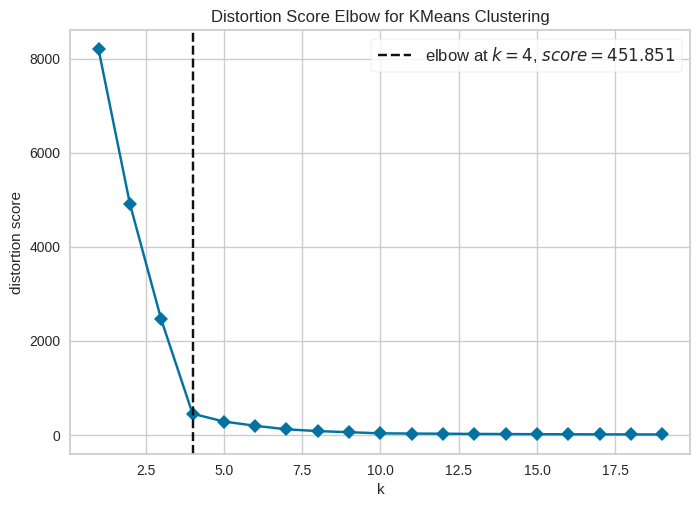

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [318]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import SilhouetteVisualizer

model = KMeans(
    init="k-means++",
    n_init=10,
    max_iter=500,
    random_state=42
)

visualizer = KElbowVisualizer(
    model,
    k=(1, 20),
    metric="distortion",
    timings=False
)

visualizer.fit(embeddings_environment_umap)
visualizer.show()

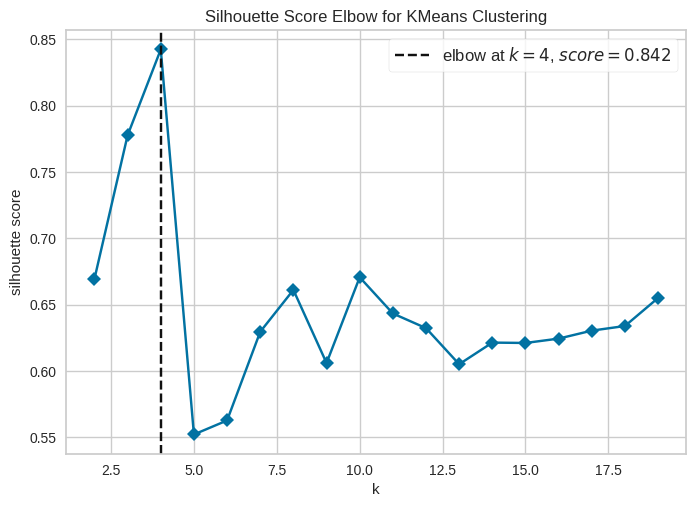

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [319]:
visualizer = KElbowVisualizer(
    model,
    k=(2, 20),
    metric="silhouette",
    timings=False,
    random_state=42
)

visualizer.fit(embeddings_environment_umap)
visualizer.show()

### **K-Means Clustering Hypertuning**

n_clusters value were chosen based on local maximums seem on silhoutte score visualization.

In [320]:
import umap
import hdbscan
import numpy as np
from sklearn.metrics import silhouette_score

n_neighbors_values = [5, 8, 10, 12]
n_components_values = [3, 6, 8]
n_clusters_values = [3, 4, 8]

In [321]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score


k_means_results = []

for n_neighbors in n_neighbors_values:
    for n_components in n_components_values:

        umap_model = umap.UMAP(
            n_neighbors=n_neighbors,
            n_components=n_components,
            min_dist=0.0,
            metric='cosine',
            random_state=42
        )

        reduced = umap_model.fit_transform(embeddings_environment)

        for n_clusters in n_clusters_values:

                clusterer = KMeans(
                   n_clusters=n_clusters,
                   init="k-means++",
                   n_init=10,
                   max_iter=500,
                   random_state=42
                )

                labels_kmeans = clusterer.fit_predict(reduced)

                silhouette = silhouette_score(
                    reduced,
                    labels_kmeans
                )

                db_k_means = davies_bouldin_score(reduced, labels_kmeans)

                ch_k_means = calinski_harabasz_score(reduced, labels_kmeans)

                k_means_results.append({
                    "n_neighbors": n_neighbors,
                    "n_components": n_components,
                    "n_clusters": n_clusters,
                    "silhouette": silhouette,
                    "davies_bouldin": db_k_means,
                    "calinski_harabasz": ch_k_means
                })

### **HDBSCAN Clustering**

In [322]:
import umap
import hdbscan
import numpy as np
from sklearn.metrics import silhouette_score

n_neighbors_values = [5, 8, 10, 12]
n_components_values = [3, 5, 8]
min_cluster_size_values = [5, 8, 10, 12]
min_samples_values = [2, 3, 5]


In [323]:
dbscan_results = []

for n_neighbors in n_neighbors_values:
    for n_components in n_components_values:

        umap_model = umap.UMAP(
            n_neighbors=n_neighbors,
            n_components=n_components,
            min_dist=0.0,
            metric='cosine',
            random_state=42
        )

        reduced = umap_model.fit_transform(embeddings_environment)

        for min_cluster_size in min_cluster_size_values:
            for min_samples in min_samples_values:

                clusterer = hdbscan.HDBSCAN(
                    min_cluster_size=min_cluster_size,
                    min_samples=min_samples,
                    metric='euclidean',
                    cluster_selection_method='eom'
                )

                labels_hdbscan = clusterer.fit_predict(reduced)

                # Skip if only 1 cluster
                num_clusters = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)

                if num_clusters < 3:
                    continue

                # Skip if too many clusters
                if num_clusters > 50:
                    continue

                # Remove noise points for silhouette score
                mask = labels_hdbscan != -1

                if len(set(labels_hdbscan[mask])) < 2:
                    continue

                silhouette = silhouette_score(
                    reduced[mask],
                    labels_hdbscan[mask]
                )

                noise_pct = np.mean(labels_hdbscan == -1)

                persistence = np.mean(clusterer.cluster_persistence_)

                db_hdbscan = davies_bouldin_score(reduced[mask], labels_hdbscan[mask])

                ch_hdbscan = calinski_harabasz_score(reduced[mask], labels_hdbscan[mask])

                dbscan_results.append({
                    "n_neighbors": n_neighbors,
                    "n_components": n_components,
                    "min_cluster_size": min_cluster_size,
                    "min_samples": min_samples,
                    "num_clusters": num_clusters,
                    "silhouette": silhouette,
                    "noise_pct": noise_pct,
                    "persistence": persistence,
                    "davies_bouldin": db_hdbscan,
                    "calinski_harabasz": ch_hdbscan
                })


### **Model Comparision**

In [364]:
dbscan_results_df = pd.DataFrame(dbscan_results)

dbscan_results_df_filtered = dbscan_results_df[(dbscan_results_df['silhouette'] > 0.8) & (dbscan_results_df['persistence'] > 0.7) & (dbscan_results_df['noise_pct'].between(0.05, 0.35))]

dbscan_results_df_filtered.sort_values(by=['silhouette', 'persistence'], ascending=[False, False])

,n_neighbors,n_components,min_cluster_size,min_samples,num_clusters,silhouette,noise_pct,persistence,davies_bouldin,calinski_harabasz
37,8,5,10,5,3,0.814376,0.127451,0.756064,0.192605,1458.242188
36,8,5,10,3,3,0.814376,0.127451,0.743717,0.192605,1458.242188
35,8,5,10,2,3,0.814376,0.127451,0.703157,0.192605,1458.242188
72,10,8,10,3,3,0.795198,0.127451,0.766725,0.214137,1023.611938
70,10,8,8,5,3,0.795198,0.127451,0.731131,0.214137,1023.611938
73,10,8,10,5,3,0.795198,0.127451,0.720685,0.214137,1023.611938
71,10,8,10,2,3,0.795198,0.127451,0.707318,0.214137,1023.611938
63,10,5,10,3,3,0.757354,0.127451,0.734087,0.243659,1243.260010
62,10,5,10,2,3,0.757354,0.127451,0.715944,0.243659,1243.260010
64,10,5,10,5,3,0.757354,0.127451,0.704652,0.243659,1243.260010


In [334]:
k_means_results_df = pd.DataFrame(k_means_results)

k_means_results_df_filtered = k_means_results_df[(k_means_results_df['silhouette'] > 0.64) & (k_means_results_df['davies_bouldin'] < 0.4) & (k_means_results_df['calinski_harabasz'] > 700)]

k_means_results_df_filtered.sort_values(by=['silhouette', 'davies_bouldin'], ascending=[False, True])

,n_neighbors,n_components,n_clusters,silhouette,davies_bouldin,calinski_harabasz
1,5,3,4,0.892949,0.101484,764.210022
34,12,8,4,0.786367,0.153963,830.965027
2,5,3,8,0.680427,0.354441,2931.884033
11,8,3,8,0.675172,0.379020,2571.509277
5,5,6,8,0.666177,0.351749,1539.244873
8,5,8,8,0.652685,0.387028,2047.175293


**DBSCAN Best Model** *(3 clusters)*

Hyperparameters:
- n_neighbors: 8
- n_componenets: 5
- min_cluster_size: 10
- min_samples: 5


**Best K-Means Model:** *(4 clusters)*
Hyperparameters:
- n_neighbors: 5
- n_componenets: 3
- n_clusters: 4


DBSCAN identified 3 clusters across almost all model hyperparameters. Because of this consistency, we will explore the DBSCAN model.


### **Best Model**

In [408]:
umap_model = umap.UMAP(
    n_components=8,
    n_neighbors=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

embeddings_environment_umap = umap_model.fit_transform(embeddings_environment)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

environment_labels = hdbscan_model.fit_predict(embeddings_environment_umap)

In [409]:
details_environment["cluster"] = environment_labels

/tmp/ipython-input-1818502482.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



### **Extracting Text for Cluster Labels**

In [411]:
# Build cluster documents
environment_cluster_docs = (
    details_environment[details_environment["cluster"] != -1]
    .groupby("cluster")["cleaned_description"]
    .apply(lambda x: " ".join(x))
)

In [412]:
# remove common phrases
PHRASE_STOPWORDS = [
    "funding opportunity",
    "funding opportunity announcement",
    "award mechanism",
    "notice of funding opportunity",
]

def remove_phrases(text):
    text = text.lower()
    for p in PHRASE_STOPWORDS:
        text = text.replace(p, " ")
    return text

environment_cluster_docs = environment_cluster_docs.apply(remove_phrases)

In [416]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

def extract_cluster_keywords(cluster_series, top_n=10):

    vec = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,2),
        min_df=1,
        max_df=1,
        sublinear_tf=True
    )

    X = vec.fit_transform(cluster_series.values)

    terms = np.array(vec.get_feature_names_out())

    results = {}

    for i, cid in enumerate(cluster_series.index):
        scores = X[i].toarray().ravel()
        top_terms = terms[scores.argsort()[-top_n:][::-1]]
        results[cid] = top_terms.tolist()

    return results

environment_keywords  = extract_cluster_keywords(environment_cluster_docs)


In [417]:
def keywords_to_df(keyword_dict):
    return (
        pd.DataFrame.from_dict(keyword_dict, orient="index")
        .reset_index()
        .rename(columns={"index":"cluster"})
    )

environment_keywords_df  = keywords_to_df(environment_keywords)

In [418]:
environment_keywords_df

,cluster,0,1,2,3,4,5,6,7,8,9
0,0,environmental education,responsible,students teachers,decisions responsible,public awareness,participants programs,issues provides,local environmental,promote environmental,financial support
1,1,research,epa,communities,climate,funding,conservation,development,species,announcement,assistance


**Analysis**

Within the two clusters identified through DBSCAN (other than noise), the sub-topics are environmental education and research & conservation.

The clusters identified in M3 and far more granular, at the expense of cluster quality. M3 clusters help us identify the niche areas where education or research may be focusing in environmental grant space, where as this clustering allows us to compare the two main avenues of environmental grants.



In [419]:
cluster_label_map = {
    0: "Environmental Education",
    1: "Research & Conservation",
}

details_environment["cluster_label"] = details_environment["cluster"].map(cluster_label_map)

details_environment["cluster_label"] = (
    details_environment["cluster_label"]
    .fillna("Noise / Unassigned")
)


/tmp/ipython-input-2379796803.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-2379796803.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



###**Cluster Analysis**

In [392]:
environment_cluster_summary = (
    details_environment.groupby("cluster_label").agg(
        n_opps=('opportunity_id', 'count'),
        avg_funding=('estimated_total_program_funding', 'mean'),
        med_funding=('estimated_total_program_funding', 'median'),
        total_funding=('estimated_total_program_funding', 'sum'),
        avg_awards=('expected_number_of_awards', 'mean'),
        med_awards=('expected_number_of_awards', 'median')
    )
    .sort_values("total_funding", ascending=False)
)

environment_cluster_summary.sort_values(by='total_funding', ascending=False)

,n_opps,avg_funding,med_funding,total_funding,avg_awards,med_awards
cluster_label,,,,,,
Research & Conservation,92,5.939275e+08,5290000.0,3.325994e+10,20.0,7.5
Environmental Education,10,3.600000e+05,360000.0,3.600000e+06,5.0,5.0


**Analysis**

Looking at the number of grants in each cluster, we can see that it is not a balanced split between Environmental Education and Research & Conversation. Research & Conservation dominates this category in number of grants, average awards, and median and total funding.

# **Key Findings from M4 phase**

**1. Density-Based clustering out performed K-Means clustering.**

DBSCAN improved clusters from M3 because it is better had handling non-spherical clusters and automatically removing noise. Text embeddings are rarely uniformly spherical, and grant descriptions in particular, may have a lot of overlap. In most categories, DBSCAN identified more informative clusters.

**2. Removing common grant phrases and sequences improved text embedding and key-word extraction interpretability.**

Adding Unicode Normalization, removing solicitation codes, and removing common un-informative grant words and phrases, improved the quality of my clusters and made subsequent key-word extraction more informative to the semantic theme of each cluster.


**3. Implementation grants dominate discovery grants in some domains**
In Education and parts of Health, funding prioritizes implementation—workforce training, program administration, and applied initiatives—over new discovery. This indicates that agencies are often focused on scaling existing knowledge rather than funding early-stage exploration.

**4. Defense & Aerospace dominate Science Grants**

While this sub-topic does not have the highest share of grants, it dominates the category in average and total funding and average number of awards, indicating it is a high priority domain for government grants.


## Widget Removal

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install nbformat

import nbformat

notebook_path = '/content/drive/MyDrive/MSBA Spring 2026/820 ML Group Project/M4 Work/Notebooks/Maggie_Croghan_M4.ipynb'  # change to your filename

nb = nbformat.read(notebook_path, as_version=4)

# Remove widgets metadata entirely
if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(nb, notebook_path)

print("Widgets metadata removed successfully.")

Widgets metadata removed successfully.
